<a href="https://colab.research.google.com/github/Nmg1994/RL-integrated-ABM/blob/main/RL_integrated_ABM_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing necessary packages

In [ ]:
!pip install rasterio
!pip install scikit-learn
!pip install scikit-survival
!pip install xgboost
!pip install randomSurvivalForest
!pip install tqdm
!pip install mesa

# Importing necessary libraries/modules

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt
import pandas as pd
import math
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
import sklearn.metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score
)

from sksurv.util import Surv
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import KBinsDiscretizer
import rasterio
from sklearn.isotonic import IsotonicRegression
from scipy.stats import rankdata, t
from statsmodels.distributions.copula.api import StudentTCopula
from statsmodels.stats.correlation_tools import cov_nearest
from scipy.interpolate import interp1d
import random
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.datacollection import DataCollector
import pickle
from collections import defaultdict
import re
import os

# Mounting Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Crop yield prediction

## Preparing Soybean yields dataset

In [ ]:
yields_all_crops_df = pd.read_csv('/content/drive/My Drive/Crop_yield_prediction_CAR/historical_actual_crop_yield_by_CAR.csv')
soybean_yields_df = yields_all_crops_df[yields_all_crops_df['CROP'] == 'soybeans']
soybean_yields_df_2011_2021_cleaned = soybean_yields_df[['CARUID',	'CROP', 'Y2011', 'Y2012', 'Y2013','Y2014', 'Y2015', 'Y2016', 'Y2017', 'Y2018', 'Y2019', 'Y2020','Y2021']]

In [ ]:
CAR_id  = soybean_yields_df_2011_2021_cleaned['CARUID'].unique()

years = ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021']
New_df = pd.DataFrame()

columns_title = ['CARUID']

for year in years:
  columns_title.append(f'Soybeans_{year}')

New_df = pd.DataFrame(columns=columns_title)
New_df['CARUID'] = CAR_id

for id in tqdm(CAR_id , desc= 'Progress'):

  if not soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')].empty:
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2011'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2011'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2012'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2012'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2013'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2013'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2014'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2014'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2015'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2015'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2016'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2016'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2017'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2017'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2018'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2018'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2019'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2019'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2020'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2020'].values[0]
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2021'] = soybean_yields_df_2011_2021_cleaned[(soybean_yields_df_2011_2021_cleaned['CARUID'] == id) & (soybean_yields_df_2011_2021_cleaned['CROP'] == 'soybeans')]['Y2021'].values[0]
  else:
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2011'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2012'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2013'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2014'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2015'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2016'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2017'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2018'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2019'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2020'] = 0
    New_df.loc[New_df['CARUID'] == id, 'Soybeans_2021'] = 0

New_df.to_csv('/content/drive/My Drive/Crop_yield_prediction_CAR/Soybean_yields_2011_2021.csv', index=False)

Progress: 100%|██████████| 26/26 [00:00<00:00, 94.33it/s]


## Loading all datasets and preprocessing them before feeding to the XGBoost model

In [ ]:
climate_variables = pd.read_csv('/content/drive/My Drive/Climate_data_after_ArcGIS_preprocessing/climate_data_structured_format_2011_2024.csv')
keywords = ["_3", "_4", "_10"]
columns_to_drop = [col for col in climate_variables.columns if any(keyword in col for keyword in keywords)]
climate_variables = climate_variables.drop(columns=columns_to_drop)
Soil_variable = pd.read_excel('/content/drive/My Drive/Soil_ABM/Soil variables.xlsx')
Honeybee_census_variable = pd.read_csv('/content/drive/My Drive/Honeybee_census_CAR/Honeybee_census_CAR.csv')

soybean_yields = pd.read_csv('/content/drive/My Drive/Crop_yield_prediction_CAR/Soybean_yields_2011_2021.csv')
soybean_yields_QC = soybean_yields[soybean_yields['CARUID'].isin(climate_variables['CAR_ID'])].reset_index(drop=True)
soybean_yields_QC = soybean_yields_QC.rename(columns={'CARUID': 'CAR_ID'})

merged_climate_and_yields = pd.merge(climate_variables, soybean_yields_QC, on='CAR_ID', how='inner')
merged_climate_yields_and_soil = pd.merge(merged_climate_and_yields, Soil_variable, on='CAR_ID', how='inner')
merged_climate_yields_soil_and_honeybee = pd.merge(merged_climate_yields_and_soil, Honeybee_census_variable, on='CAR_ID', how='inner')
merged_climate_yields_soil_and_honeybee.to_csv('/content/drive/My Drive/Crop_yield_prediction_CAR/All_variables_merged.csv', index=False)

In [ ]:
All_variables_df = pd.read_csv('/content/drive/My Drive/Crop_yield_prediction_CAR/All_variables_merged.csv')
All_variables_prepared = pd.DataFrame()

for y in tqdm([2011, 2016, 2021], desc='Year processing'):
  df_prepared = pd.DataFrame()
  df_prepared['CAR_ID'] = All_variables_df['CAR_ID'].copy()
  df_prepared['Year'] = y
  df_prepared['Precipitation'] = All_variables_df.filter(regex=f'Total Prcp_{y}_').mean(axis = 1).copy()
  df_prepared['T_max'] = All_variables_df.filter(regex=f'Tmax_{y}_').mean(axis = 1).copy()
  df_prepared['Saturated hydraulic conductivity'] = All_variables_df['Saturated hydraulic conductivity'].copy()
  df_prepared['Honeybee census'] = All_variables_df[f'Honeybee census_{y}'].copy()
  df_prepared['Yields'] = All_variables_df[f'Soybeans_{y}'].copy()

  All_variables_prepared = pd.concat([All_variables_prepared, df_prepared], axis=0, ignore_index=True)

All_variables_prepared.to_csv(f'/content/drive/My Drive/Crop_yield_prediction_CAR/All_variables_prepared_2011_2021.csv', index=False)

Year processing: 100%|██████████| 3/3 [00:00<00:00, 186.09it/s]


## Training the XGBoost model and evaluating its performance through test dataset

In [4]:
All_variables_prepared = pd.read_csv('/content/drive/My Drive/Crop_yield_prediction_CAR/All_variables_prepared_2011_2021.csv')
All_variables_prepared_bootstarp = All_variables_prepared.sample(n=150, replace=True)
X = All_variables_prepared_bootstarp.drop(columns= ['CAR_ID', 'Yields']).copy()
Y = All_variables_prepared_bootstarp['Yields'].copy()
# Splitting dataset into training and test datasets with the portion 70:30
X_training, X_test, Y_training, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, shuffle = True)
print(f'Training dataset shape: {X_training.shape}, {Y_training.shape}')
print(f'Test dataset shape: {X_test.shape}, {Y_test.shape}')

Training dataset shape: (105, 5), (105,)
Test dataset shape: (45, 5), (45,)


## Hyper-parameter tuning and accuracy assessment of the models with optimized values for the hyper-parameters on both training and test datasets

In [5]:
# Function to calculate and print metrics
def print_metrics(y_test, y_pred):
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  print(f"Mean Absolute Error (MAE): {mae}")
  print(f"Root Mean Squared Error (RMSE): {rmse}")
  print(f"R2 Score: {r2}")
  print("-" * 30)

In [6]:
# XGBoost model
parameters = {'n_estimators': np.arange(100, 501, 100), 'max_depth': np.arange(1,30,4)}
XGBoost_regressor = xgb.XGBRegressor(random_state=42)
XGBoost_model_gs = GridSearchCV(XGBoost_regressor, parameters, scoring='neg_mean_squared_error', cv=10, return_train_score=True, n_jobs=-1, verbose=1)

XGBoost_model_gs.fit(X_training, Y_training)

print("Best Parameters:", XGBoost_model_gs.best_params_)
print("Best Score:", XGBoost_model_gs.best_score_)

Best_XGBoost = XGBoost_model_gs.best_estimator_

print('Accuracy on training dataset')
y_pred_training = Best_XGBoost.predict(X_training)
print_metrics(Y_training, y_pred_training)

print('Accuracy on test dataset')
y_pred = Best_XGBoost.predict(X_test)
print_metrics(Y_test, y_pred)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best Parameters: {'max_depth': np.int64(1), 'n_estimators': np.int64(500)}
Best Score: -0.5546947562252134
Accuracy on training dataset
Mean Absolute Error (MAE): 0.11078960600353427
Root Mean Squared Error (RMSE): 0.1617667909377354
R2 Score: 0.9992276469736251
------------------------------
Accuracy on test dataset
Mean Absolute Error (MAE): 0.12857862684461815
Root Mean Squared Error (RMSE): 0.19302283008665685
R2 Score: 0.9990010908168456
------------------------------


# Beehive mortality assessment

## Beehive dataset preparation

In [ ]:
# Defining a custom date parsing function
def parse_datetime(dt):
  return pd.to_datetime(dt.split(' ', 1)[0])  # Splitting the string at the first space character

# Reading the dataframe with the custom parsing function
Quebec_df = pd.read_csv("/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/latest_Nectar_dataset_Specific_for_Navid_ABM_Quebec_samples.csv", parse_dates=['report_submitted_at'], date_parser=parse_datetime)

# Exporting dataframes to the Google Drive, avoiding to repeat doing the same preprocessing later
Quebec_df.to_csv("/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Quebec_samples_date_format_modified.csv", index=False)

In [ ]:
Quebec_df = pd.read_csv("/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Quebec_samples_date_format_modified.csv", low_memory=False)
# Further preprocessing of beehive data defining a function

def preprocessing_dataframe(DF):
  DF = DF.drop(['tag_serial_number', 'bottle_id','fob', 'fobr', 'brood_pattern','grade','varroa', 'category','action_detail','yard_name', 'report_notes', 'report_report_type', 'operation_id', 'queen_management', 'queen_status', 'state_province_long', 'country_long', 'city', 'yard_type', 'crop_type', 'pounds_of_honey'], axis=1)

  # Replace "<Null>" values with np.nan
  DF.replace('<Null>', np.nan, inplace=True)

  # Droping the rows containing NaN in any column
  DF.dropna(inplace=True)

  Data_frame = DF.sort_values(by = 'report_submitted_at', axis = 0, ascending=True).reset_index(drop = True)

  # Converting the datetime column to datetime format
  Data_frame['report_submitted_at'] = pd.to_datetime(Data_frame['report_submitted_at'])

  # Extracting the year and month into separate columns
  Data_frame['year'] = Data_frame['report_submitted_at'].dt.year
  Data_frame['month'] = Data_frame['report_submitted_at'].dt.month

  # Adding month-year column
  Data_frame['YearMonth'] = pd.to_datetime(Data_frame.report_submitted_at).apply(lambda x: '{year}-{month}'.format(year=x.year, month=x.month))

  # Subseting deadouts only
  dfdo = Data_frame[(Data_frame.is_alive == 0)]
  # Counting number of rows per month per operation
  deadouts_month = dfdo.groupby(['YearMonth'])['report_submitted_at'].size().sort_index().reset_index()

  #Sorting dates
  deadouts_month['YearMonth'] = pd.to_datetime(deadouts_month['YearMonth']).dt.strftime("%Y-%m")
  deadouts_month = deadouts_month.set_index('YearMonth').sort_index().reset_index()
  print(deadouts_month)
  # Annual deadouts

  for y in Data_frame['year'].unique():
    print('Number of dead hives in the year ' f'{y}' ' is: ', Data_frame[(Data_frame['year'] == y) & (Data_frame['is_alive'] == 0)].shape[0])

  # Total hives annually
  for y in Data_frame['year'].unique():
    print('Number of total hives in the year ' f'{y}' ' is: ', Data_frame[Data_frame['year'] == y]['hive_identity_id'].drop_duplicates().shape[0]) # or using .unique().shape[0] instead of .drop_duplicates().shape[0]

  # plotting
  ax = sns.barplot(data=deadouts_month, y="report_submitted_at", x= 'YearMonth')
  ax.set(xlabel='Date', ylabel='Number of scanned deadouts', title = "Dead hive scans per month")
  plt.xticks(rotation=45, ha='right')
  plt.show()
  Data_frame.drop(columns=['report_submitted_at','YearMonth'], inplace=True)
  return Data_frame

In [ ]:
Quebec_preprocessed_df = preprocessing_dataframe(Quebec_df)
Quebec_preprocessed_df[(Quebec_preprocessed_df['year'] == 2023) | (Quebec_preprocessed_df['year'] == 2024)].to_csv("/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Quebec_samples_2023_2024.csv", index=False)

## Preprocessing of the DEM and climate variables (2023-2024) averaged in 1.5 Km buffer of the beehives

In [ ]:
climate_data_beehives = pd.DataFrame()

for year in tqdm(range(2023, 2025), desc = 'Year: '):
  for month in range(3, 11):
    monthly_Tmax = pd.read_excel(f'/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/MeanTmax_{year}_{month}.xls')
    monthly_Prec = pd.read_excel(f'/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Total_Prcp_{year}_{month}.xls')

    monthly_Tmax_df = monthly_Tmax[['hive_identity_id', 'MEAN']].copy()
    monthly_Prec_df = monthly_Prec[['hive_identity_id', 'MEAN']].copy()

    monthly_Tmax_df = monthly_Tmax_df.rename(columns={'MEAN': f'Tmax_{year}_{month}'})
    monthly_Prec_df = monthly_Prec_df.rename(columns={'MEAN': f'Total Prcp_{year}_{month}'})

    monthly_climate_variables = monthly_Tmax_df.merge(monthly_Prec_df, on='hive_identity_id', how='inner')

    if climate_data_beehives.empty:
      climate_data_beehives = monthly_climate_variables.copy()
    else:
      climate_data_beehives = climate_data_beehives.merge(monthly_climate_variables, on='hive_identity_id', how='inner')

climate_data_beehives.to_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/climate_data_beehives.csv', index= False)

Year: 100%|██████████| 2/2 [00:29<00:00, 14.63s/it]


In [ ]:
climate_data_beehives = pd.read_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/climate_data_beehives.csv')
DEM_df = pd.read_excel(f'/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Zonal_statistics_DEM_Beehive.xls')
DEM = DEM_df[['hive_identity_id', 'MEAN']].copy()
DEM = DEM.rename(columns={'MEAN': 'DEM'})
climate_data_beehives = climate_data_beehives.merge(DEM, on='hive_identity_id', how='inner')

In [ ]:
Beehive_variables_prepared = pd.DataFrame()

for y in tqdm(range(2023, 2025), desc='Year processing'):
  for m in range(3,11):
    df_prepared = pd.DataFrame()
    df_prepared['hive_identity_id'] = climate_data_beehives['hive_identity_id'].copy()
    df_prepared['Year'] = y
    df_prepared['Month'] = m
    df_prepared['DEM'] = climate_data_beehives.filter(regex=f'DEM').copy() #Constant value for all years/months
    df_prepared['Precipitation'] = climate_data_beehives.filter(regex=f'Total Prcp_{y}_{m}').copy()
    df_prepared['T_max'] = climate_data_beehives.filter(regex=f'Tmax_{y}_{m}').copy()

    Beehive_variables_prepared = pd.concat([Beehive_variables_prepared, df_prepared], axis=0, ignore_index=True)

Beehive_variables_prepared.to_csv(f'/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Beehive_variables_prepared_2023_2024.csv', index=False)

Year processing: 100%|██████████| 2/2 [00:00<00:00, 14.32it/s]


##Synthetic beehive dataset generation

In [ ]:
Beehive_variables_prepared = pd.read_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Beehive_variables_prepared_2023_2024.csv')
Qc_samples_2023_2024 = pd.read_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Quebec_samples_2023_2024.csv', low_memory=False)
Qc_samples_2023_2024_Mar_Oct = Qc_samples_2023_2024[(Qc_samples_2023_2024['month'] > 2) & (Qc_samples_2023_2024['month'] < 11)]
Qc_samples_2023_2024_Mar_Oct.to_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Quebec_samples_2023_2024_Mar_Oct.csv', index=False)
Qc_samples = Qc_samples_2023_2024_Mar_Oct.drop(columns=['lat', 'lon']).reset_index(drop=True) # Due to confidential policy
Qc_samples = Qc_samples.rename(columns={'year': 'Year', 'month': 'Month'})
Qc_samples_with_variables = Qc_samples.merge(Beehive_variables_prepared, on=['hive_identity_id', 'Year', 'Month'], how='inner')
Qc_samples_with_variables = Qc_samples_with_variables.drop_duplicates().reset_index(drop=True)
Qc_samples_with_variables = Qc_samples_with_variables.drop(columns=['hive_identity_id'])
Qc_samples_with_variables.to_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Qc_samples_with_variables.csv', index=False)

In [ ]:
# Function converting data to uniform margins using empirical CDF (Rank transformation)
def empirical_cdf_transform(data):
    return np.array([rankdata(data[col], method="average") / len(data) for col in data]).T

uniform_Qc_samples_with_variables = empirical_cdf_transform(Qc_samples_with_variables)
columns = Qc_samples_with_variables.columns
# Estimating the correlation matrix for T-Copula
corr_matrix = np.corrcoef(uniform_Qc_samples_with_variables, rowvar=False)
corr_matrix = cov_nearest(corr_matrix)  # Ensuring it is a valid correlation matrix

# Fitting a T-Copula model
df_t = 5  # Degrees of freedom
copula = StudentTCopula(corr_matrix, df_t)

# Generating synthetic samples
synthetic_uniform = copula.rvs(len(Qc_samples_with_variables))


# Transforming synthetic data back to original distribution
synthetic_real = np.zeros_like(synthetic_uniform)

for i, col in enumerate(columns):
    original = Qc_samples_with_variables[col].values
    synthetic_real[:, i] = np.interp(synthetic_uniform[:, i], np.linspace(0, 1, len(original)), np.sort(original))

synthetic_df = pd.DataFrame(synthetic_real, columns=columns)
synthetic_df.to_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/synthetic_beehive_dataset.csv', index=False)

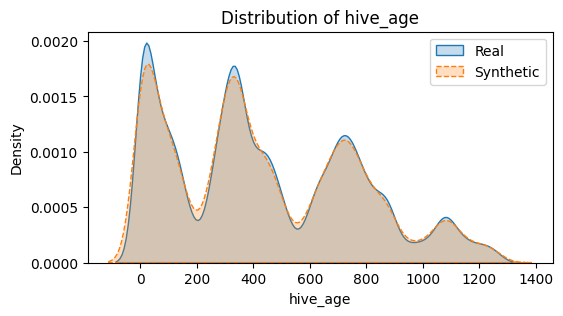

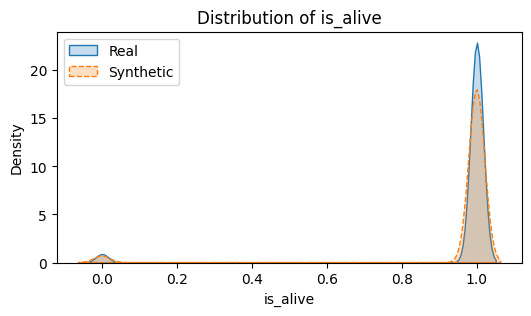

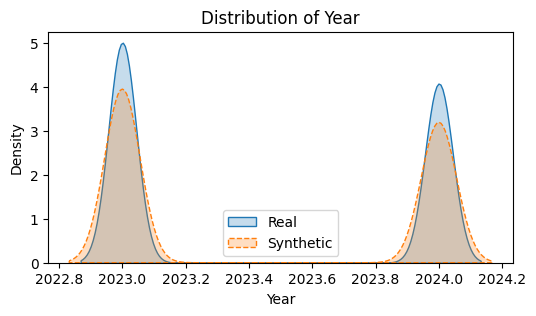

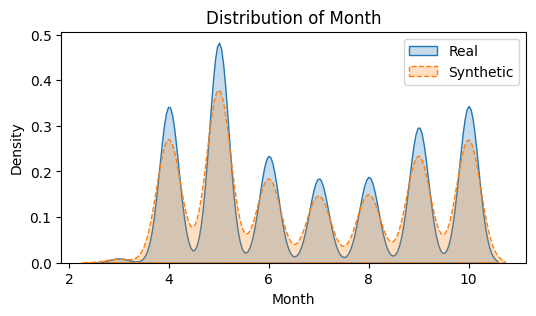

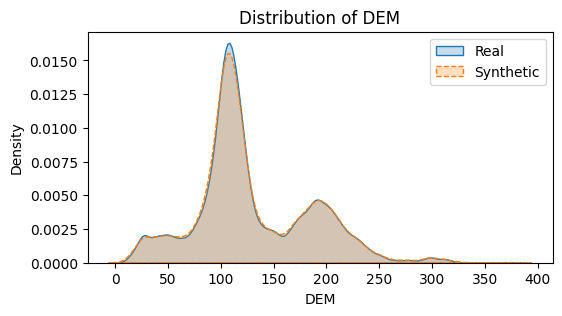

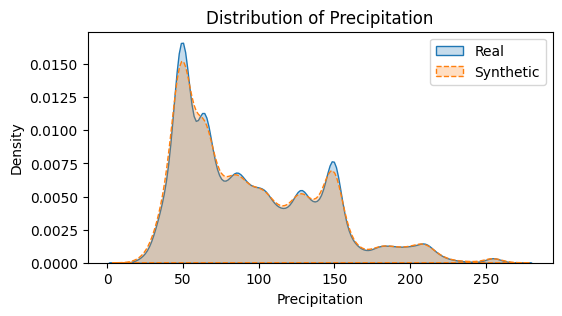

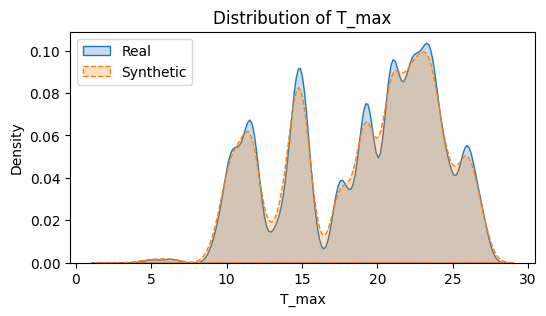

In [ ]:
# Comparing real and synthetic distributions
for col in columns:
  plt.figure(figsize=(6, 3))
  sns.kdeplot(Qc_samples_with_variables[col], label="Real", fill=True)
  sns.kdeplot(synthetic_df[col], label="Synthetic", fill=True, linestyle="dashed")
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Density")
  plt.legend()
  plt.show()

###Assessing synthetic dataset similarity to the real beehive dataset

In [ ]:
# Compute descriptive statistics
real_stats = pd.DataFrame({
    "Mean": Qc_samples_with_variables.mean(),
    "Std Dev": Qc_samples_with_variables.std(),
    "Skewness": Qc_samples_with_variables.skew(),
    "Kurtosis": Qc_samples_with_variables.kurt()
})

synthetic_stats = pd.DataFrame({
    "Mean": synthetic_df.mean(),
    "Std Dev": synthetic_df.std(),
    "Skewness": synthetic_df.skew(),
    "Kurtosis": synthetic_df.kurt()
})

# Compute absolute difference
diff_stats = abs(real_stats - synthetic_stats)

# Print results
print("\nAbsolute Differences in Descriptive Statistics:\n", diff_stats)



Absolute Differences in Descriptive Statistics:
                    Mean   Std Dev  Skewness  Kurtosis
hive_age       0.170643  0.009867  0.000289  0.002423
is_alive       0.000180  0.000438  0.013296  0.130270
Year           0.001244  0.000126  0.005044  0.002086
Month          0.000813  0.001930  0.003224  0.003495
DEM            0.127790  0.110637  0.012749  0.011850
Precipitation  0.060611  0.023671  0.003459  0.017409
T_max          0.007971  0.018742  0.003695  0.008538


In [ ]:
from scipy.stats import ks_2samp

for col in Qc_samples_with_variables.columns:
    stat, p_value = ks_2samp(Qc_samples_with_variables[col], synthetic_df[col])
    print(f"{col}: KS Statistic = {stat:.4f}, p-value = {p_value:.4f}")

hive_age: KS Statistic = 0.0023, p-value = 0.9766
is_alive: KS Statistic = 0.0002, p-value = 1.0000
Year: KS Statistic = 0.0013, p-value = 1.0000
Month: KS Statistic = 0.0014, p-value = 1.0000
DEM: KS Statistic = 0.0042, p-value = 0.4435
Precipitation: KS Statistic = 0.0026, p-value = 0.9254
T_max: KS Statistic = 0.0046, p-value = 0.3321


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
real_pca = pca.fit_transform(Qc_samples_with_variables)
synthetic_pca = pca.transform(synthetic_df)

plt.figure(figsize=(8,6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, label="Real Data")
plt.scatter(synthetic_pca[:, 0], synthetic_pca[:, 1], alpha=0.5, label="Synthetic Data")
plt.legend()
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection of Real vs. Synthetic Data")
plt.show()

In [ ]:
from scipy.spatial.distance import jensenshannon
import numpy as np

for col in Qc_samples_with_variables.columns:
    real_hist, _ = np.histogram(Qc_samples_with_variables[col], bins=50, density=True)
    synthetic_hist, _ = np.histogram(synthetic_df[col], bins=50, density=True)
    js_div = jensenshannon(real_hist, synthetic_hist)
    print(f"{col}: JS Divergence = {js_div:.4f}")

hive_age: JS Divergence = 0.0100
is_alive: JS Divergence = 0.0003
Year: JS Divergence = 0.0026
Month: JS Divergence = 0.0041
DEM: JS Divergence = 0.0124
Precipitation: JS Divergence = 0.0518
T_max: JS Divergence = 0.1052


##Fitting a Random Survival Forest model to the synthetic datasets

In [7]:
#Loading synthetic datasets
#synthetic_df = pd.read_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/synthetic_beehive_dataset.csv')
synthetic_df_all = pd.read_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/Qc_samples_with_variables.csv')
synthetic_df = synthetic_df_all.sample(frac=0.1, random_state=42)
synthetic_df['Dead'] = 1 - synthetic_df['is_alive'] # considering dead as event
synthetic_df['Dead'] = synthetic_df['Dead'].astype(int)
synthetic_df['hive_age'] = synthetic_df['hive_age'].astype(int)
synthetic_df = synthetic_df.drop(columns=['is_alive'])

In [8]:
#Splitting datasets for the configuration including beehive management criteria
X = np.array(synthetic_df.drop(columns=['hive_age', 'Dead']))
# Structured array of target variable
Y = Surv.from_arrays(synthetic_df['Dead'], synthetic_df['hive_age'])  # survival outcome (event and time)

# Initial split: Training and Testing datasets (70:30)
X_training, X_testing, Y_training, Y_testing = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state=0)

# Shape of datasets
print('X_training shape: ', X_training.shape)
print('Y_training shape: ', Y_training.shape)
print('X_testing shape: ', X_testing.shape)
print('Y_testing shape: ', Y_testing.shape)



X_training shape:  (12966, 5)
Y_training shape:  (12966,)
X_testing shape:  (5557, 5)
Y_testing shape:  (5557,)


In [ ]:
# Optimizing hyper-parameters of the RSF
parameters = {'n_estimators':np.arange(100,500,50), 'max_depth':np.arange(1,30,4)}
RSF = RandomSurvivalForest(random_state=0, bootstrap = True)
RSF_model_gs = GridSearchCV(RSF, parameters, cv=5, return_train_score=True, n_jobs=-1)
RSF_model_gs.fit(X_training, Y_training)
RSF_model_gs.best_params_
# Printing the best hyperparameters found
print("Best hyperparameters:", RSF_model_gs.best_params_)
print("\n")

# Printing the best cross-validated score
print("Best cross-validated score (concordance index):", RSF_model_gs.best_score_)

# Extracting the cross-validation results
cv_results = RSF_model_gs.cv_results_

mean_val_scores = cv_results['mean_test_score']
std_val_scores = cv_results['std_test_score']
params = cv_results['params']

# Creating a DataFrame to store the results
RF_Hyperparameters_results = pd.DataFrame({'Parameters': params, 'Mean Accuracy': mean_val_scores, 'Std Dev Accuracy': std_val_scores})
RF_Hyperparameters_results.to_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/hyperparameters.csv', index=False)

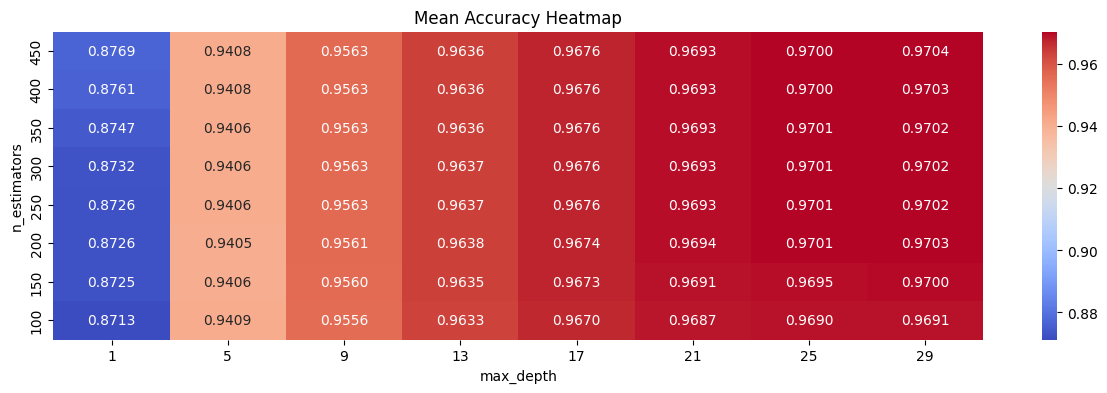

In [ ]:
# Creating a DataFrame to store the results
RF_Hyperparameters_results = pd.read_csv('/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/hyperparameters.csv')

# Extract parameters
RF_Hyperparameters_results['max_depth'] = RF_Hyperparameters_results['Parameters'].str.extract(r"'max_depth': (\d+)", expand=False).astype(int)
RF_Hyperparameters_results['n_estimators'] = RF_Hyperparameters_results['Parameters'].str.extract(r"'n_estimators': (\d+)", expand=False).astype(int)

# Pivot table for heatmap
heatmap_data = RF_Hyperparameters_results.pivot(index="n_estimators", columns="max_depth", values="Mean Accuracy")
# Sort values to ensure n_estimators is in ascending order
heatmap_data = heatmap_data.sort_index(ascending=True)

# Plot heatmap
plt.figure(figsize=(15, 4))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt=".4f")
# Reverse the y-axis to ensure lower values are at the bottom
plt.gca().invert_yaxis()
plt.title("Mean Accuracy Heatmap")
plt.xlabel("max_depth")
plt.ylabel("n_estimators")
plt.show()

In [9]:
# Fitting a RSF model to the training dataset with the optimized values for the hyper-parameters
RSF_model = RandomSurvivalForest(random_state=42, n_estimators = 100, max_depth = 5, bootstrap = True)
RSF_model.fit(X_training, Y_training)

RandomSurvivalForest(max_depth=5, random_state=42)

###Evaluation of RSF model's accuracy

In [11]:
def evaluation_model(model, X_train, X_test, Y_train, Y_test):
  # Calculating the Concordance index (C-index)
  c_index = concordance_index_censored(Y_test["event"], Y_test["time"], model.predict(X_test))
  print("Concordance index (C-index):", c_index[0])

  # Getting the probability of event-free survival for the testing dataset (apply calibration)
  surv_funcs = model.predict_survival_function(X_test)

  # Finding the range of follow-up times in Y_test
  min_time_test = int(Y_test['time'].min())
  max_time_test = int(Y_test['time'].max())

  # Ensuring that times are within the follow-up time range of Y_test
  times = np.array([t for t in model.unique_times_ if min_time_test <= t < max_time_test])
  preds = np.asarray([[fn(t) for t in times] for fn in surv_funcs])

  if len(times) == 0:
    raise ValueError("No times found within the follow-up range.")

  # Computing the integrated Brier score (IBS) using calibrated probabilities
  ibs = integrated_brier_score(Y_train, Y_test, preds, times)
  print("Integrated Brier Score (IBS):", ibs)

  # Calculating Time-dependent AUC (apply calibration)
  aucs_test = cumulative_dynamic_auc(Y_train, Y_test, model.predict(X_test), times)[0]

  # Handling NaN values in AUCs
  valid_indices_test = ~np.isnan(aucs_test)
  valid_aucs_test = aucs_test[valid_indices_test]

  # Calculating the mean AUC over the entire time range
  mean_auc_test = np.mean(valid_aucs_test)
  print("Mean Time-dependent AUC:", mean_auc_test)

  return c_index, mean_auc_test, ibs


In [ ]:
# Accuracy assessment of both training and test datasets
c_index_training, Time_dependent_training, ibs_training = evaluation_model(model = RSF_model, X_train = X_training, X_test = X_training, Y_train = Y_training, Y_test = Y_training)
c_index_test, Time_dependent_test, ibs_test = evaluation_model(model = RSF_model, X_train = X_training, X_test = X_testing, Y_train = Y_training, Y_test = Y_testing)

In [ ]:
def Plotting_AUC(model, X_train, X_test, Y_train, Y_test):

  # Finding the range of follow-up times in Y_train and Y_test
  min_time_train = int(Y_train['time'].min())
  max_time_train = int(Y_train['time'].max())

  min_time_test = int(Y_test['time'].min())
  max_time_test = int(Y_test['time'].max())

  # Ensuring times are within the follow-up time range
  times = np.array([t for t in model.unique_times_ if min_time_train <= t < max_time_train])

  if len(times) == 0:
      raise ValueError("No times found within the follow-up range.")

  # Calculating time-dependent AUC for training and test datasets
  aucs_train = cumulative_dynamic_auc(Y_train, Y_train, model.predict(X_train), times)[0]
  aucs_test = cumulative_dynamic_auc(Y_train, Y_test, model.predict(X_test), times)[0]

  # Excluding NaN values from AUCs
  valid_aucs_train = aucs_train[~np.isnan(aucs_train)]
  valid_aucs_test = aucs_test[~np.isnan(aucs_test)]

  # Calculating the mean AUC over the entire time range
  mean_auc_train = np.mean(valid_aucs_train)
  mean_auc_test = np.mean(valid_aucs_test)

  print("Mean AUC Training:", mean_auc_train)
  print("Mean AUC Test:", mean_auc_test)

  # Plotting the Time-dependent AUC for all datasets
  plt.figure(figsize=(10, 6))
  plt.plot(times, aucs_train, label='Training dataset')
  plt.plot(times, aucs_test, label='Test dataset')
  plt.xlabel('Hive age (days)', fontsize=14)
  plt.ylabel('Time-dependent AUC', fontsize=14)
  plt.yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=12)
  plt.xticks(fontsize=12)
  plt.title('Time-dependent AUC curve', fontsize=14)
  plt.legend()
  plt.grid(False)
  plt.show()

Mean AUC Training: 0.9897321452411261
Mean AUC Test: 0.9679898663451224


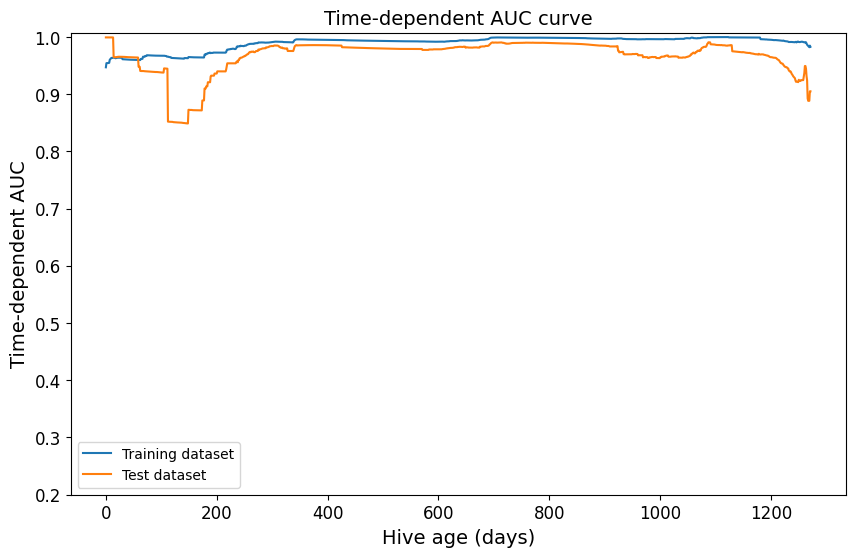

In [ ]:
# Plotting the Time-dependent AUC
Plotting_AUC(model = RSF_model, X_train = X_training, X_test = X_testing, Y_train = Y_training, Y_test = Y_testing)

### RSF model calibration

In [10]:
# Calibration of RSF model even if its accuracy is high
def calibrate_rsf_model(rsf_model, X_training, Y_training):
  # Predict survival probabilities on the training data
  pred_surv_probs = rsf_model.predict_survival_function(X_training, return_array=True)

  # Prepare the true survival probabilities for calibration
  Y_training_real = Surv.from_arrays(event=Y_training['event'], time=Y_training['time'])
  unique_times_real = np.unique(Y_training['time'])
  mean_true_surv_probs = np.array([np.mean(Y_training['time'] >= t) for t in unique_times_real])

  # Interpolate predicted probabilities to align with the true survival times
  interp_func = interp1d(rsf_model.unique_times_, np.mean(pred_surv_probs, axis=0), kind='nearest', fill_value='extrapolate')
  pred_surv_probs_interp = interp_func(unique_times_real)

  # Apply isotonic regression for calibration
  iso_reg = IsotonicRegression(out_of_bounds='clip')
  iso_reg.fit(pred_surv_probs_interp, mean_true_surv_probs)

  # Save the isotonic model and unique_times_real together
  calibration_data = {"iso_reg": iso_reg, "unique_times_real": unique_times_real}

  with open("/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/calibration_data.pkl", "wb") as f:
      pickle.dump(calibration_data, f)

  return iso_reg, unique_times_real

# Apply calibration
iso_reg_model, unique_times_real = calibrate_rsf_model(RSF_model, X_training, Y_training)

#Agent-based modeling

## Crop yield prediction function

In [ ]:
# Yield prediction function for the given CAR, year, RCP scenario, and the number of beehives provided in the pollination services
# This function is going to be called in the agent-based model
def crop_yield_prediction(XGBoost_model, year, Prcp, T_max, soil, Num_hives): # Best_XGBoost is the trained model with the optimal hyperparameters
  # Create a row DataFrame
  annual_yield = pd.DataFrame([{
      "Year": year,
      "Precipitation":Prcp,
      "T_max": T_max,
      "Saturated hydraulic conductivity": soil,
      "Honeybee census": Num_hives,
  }])

  yield_pred = XGBoost_model.predict(annual_yield)
  if yield_pred < 0: # Yield prediction cannot be negative
    yield_pred = 0
  return yield_pred[0]

## Prediction function of beehive survival probability

In [ ]:
# Defining a function for the calculation of beehive survival probability for the given CAR in the given year
# This function is going to be called in the agent-based model
def Beehive_survival_prediction(RSF_model, year, month, DEM, Prcp, T_max):
  monthly_survival_probability = pd.DataFrame([{
      "Year": year,
      "Month":month,
      "DEM": DEM,
      "Precipitation": Prcp,
      "T_max": T_max,
  }])

  # Load the calibration model and unique_times_real
  with open("/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/calibration_data.pkl", "rb") as f:
    calibration_data = pickle.load(f)

  iso_reg_model = calibration_data["iso_reg"]
  unique_times_real = calibration_data["unique_times_real"]

  # Predict survival probabilities on new data
  pred_surv_probs_new = RSF_model.predict_survival_function(monthly_survival_probability.values)

  for _,sf in enumerate(pred_surv_probs_new):
    # Interpolate predictions to match calibration times
    interp_func_new = interp1d(RSF_model.unique_times_, sf.y, kind='nearest', fill_value='extrapolate')
    pred_surv_probs_new_interp = interp_func_new(unique_times_real)

    # Apply the saved isotonic regression model for calibration
    calibrated_pred_surv_probs = iso_reg_model.transform(pred_surv_probs_new_interp)

  return np.mean(calibrated_pred_surv_probs) #monthly survival probability for July and August

## Developing the RL integrated Agent-based model (RL-ABM)

In [17]:
class ContextualBanditAgent(Agent):

    def __init__(self, model, region):

        # Modern Mesa automatically assigns unique_id
        super().__init__(model)

        self.region = region

        # State-action value table
        self.q_table = {}

        # These can later be modified during training
        self.exploration_rate = 1.0
        self.learning_rate = 1.0

        # Storage
        self.rewards = []
        self.rewards_history = []

        self.q_values = []
        self.q_values_history = []

        self.actions_taken = []
        self.actions_taken_history = []


    @classmethod
    def create_agents(cls, model, n, region):

        agents = []

        for _ in range(n):
          agent = cls(model=model,region=region)
          agents.append(agent)

        return agents

    # ACTION SELECTION

    def choose_action(self, state, possible_actions):
      # epsilon-greedy action selection
      if self.random.random() >= self.exploration_rate:
          # Exploitation
          return self.get_best_action(state,possible_actions)
      else:
          # Exploration
          return self.random.choice(possible_actions)


    # BEST ACTION

    def get_best_action(self, state, possible_actions):

      state_key = tuple(state)

      # Initialize unseen state
      if state_key not in self.q_table:

          self.q_table[state_key] = {
              action: 0.0
              for action in possible_actions
          }

      # Find maximum Q-value
      max_q = max(
          self.q_table[state_key][action]
          for action in possible_actions
      )

      # Identify all actions sharing the maximum Q-value
      best_actions = [
          action
          for action in possible_actions
          if np.isclose(
              self.q_table[state_key][action],
              max_q
          )
      ]

      # Random tie-breaking
      return self.random.choice(best_actions)


    # --------------------------------------------------------
    # STATE-ACTION VALUE UPDATE
    # --------------------------------------------------------

    def update_q_table(self,state,action,reward,possible_actions):

        """
        Incremental state-action value update:

        Q(s,a) =(1-alpha) * Q(s,a) + alpha * R

        NOTE:
        This is intentionally NOT conventional temporal-
        difference Q-learning because the next-state value
        and discount factor are not included.

        The formulation is therefore treated as contextual
        state-action value learning / contextual bandit
        learning.
        """

        state_key = tuple(state)

        # Initialize unseen state
        if state_key not in self.q_table:

            self.q_table[state_key] = {
                action: 0.0
                for action in possible_actions
            }

        current_q = (self.q_table[state_key][action])

        new_q = ((1 - self.learning_rate)* current_q+self.learning_rate* reward)
        self.q_table[state_key][action] = new_q
        self.q_values.append(new_q)

# ============================================================
# FARMER AGENT
# ============================================================

class FarmerAgent(ContextualBanditAgent):

    def __init__(self, model, region):

        super().__init__(model,region)
        self.possible_actions = [(0, 0),(1, 2000),(1, 6000),(1, 10000)]

    def step(self):

        state = (self.region.annual_precipitation,self.region.annual_temperature,self.region.soil)
        action = self.choose_action(state,self.possible_actions)
        self.actions_taken.append(action[1])
        self.region.pollination_requests = (action)

# ============================================================
# BEEKEEPER AGENT
# ============================================================

class BeekeeperAgent(ContextualBanditAgent):

    def __init__(self, model, region):

        super().__init__(model,region)
        self.chosen_month = None
        self.possible_actions = [(0, 0),(1, 2000),(1, 6000),(1, 10000)]

    def step(self):

        self.chosen_month = self.random.choice([7, 8])

        if self.chosen_month == 7:
            state = (self.region.DEM,self.region.July_precipitation,self.region.July_temperature,7)
        else:
            state = (self.region.DEM,self.region.August_precipitation,self.region.August_temperature,8)

        action = self.choose_action(state,self.possible_actions)
        self.actions_taken.append(action[1])
        self.region.pollination_offers = (action)

class PollinationModel(Model):

    def __init__(self,rng=None,survival_threshold=0.70,farmer_reward_cap=2.0,beekeeper_reward_cap=2.0,scale_beekeeper_reward_by_hives=True):

        super().__init__(rng=rng)
        self.current_year = 2025

        self.survival_threshold = (survival_threshold)

        # Symmetric reward bounds

        self.farmer_reward_cap = (farmer_reward_cap)
        self.beekeeper_reward_cap = (beekeeper_reward_cap)

        # Determines whether beekeeper reward magnitude
        # depends on realized hive deployment.

        self.scale_beekeeper_reward_by_hives = (scale_beekeeper_reward_by_hives)

        # Maximum deployment represented in action space
        self.max_hives = 10000

        self.regions = [Region(region_id=i) for i in [2402,2403,2404,2405,2406,2408,2409,2410,2411]]


        # AGENT STORAGE
        self.farmers = []
        self.beekeepers = []
        self.agents_list = []


        # CREATE AGENTS

        for region in self.regions:

            farmer = (FarmerAgent.create_agents(model=self,n=1,region=region))
            beekeeper = (BeekeeperAgent.create_agents(model=self,n=1,region=region))

            self.farmers.extend(farmer)
            self.beekeepers.extend(beekeeper)

            self.agents_list.extend(farmer)
            self.agents_list.extend(beekeeper)

    # MODEL STEP
    def step(self):

        # Update environmental conditions for year
        self.update_environment(self.current_year)

        # Farmers make decisions
        for farmer_agent in self.farmers:
            farmer_agent.step()

        # Beekeepers make decisions
        for beekeeper_agent in self.beekeepers:
            beekeeper_agent.step()

        # Process interaction
        self.process_pollination()

        # Advance one year
        self.current_year += 1


    # FARMER-BEEKEEPER INTERACTION

    def process_pollination(self):

        for regionn in self.regions:

            # RETRIEVE AGENT DECISIONS

            F_requested, F_n = (regionn.pollination_requests)
            B_offered, B_n = (regionn.pollination_offers)

            # REALIZED POLLINATION SERVICE

            # Service exists only when:
            # Farmer requests AND beekeeper offers.
            # Realized hives are limited by whichever quantity is smaller.

            if (F_requested == 1 and B_offered == 1):
                matched_hives = min(F_n,B_n)
            else:
                matched_hives = 0

            # Explicitly store realized service

            regionn.realized_hives = (matched_hives)

            # FARMER REWARD
            for farmer in self.farmers:
                if (farmer.region.id!=regionn.id):
                    continue

                # Farmer state
                F_state = (farmer.region.annual_precipitation,farmer.region.annual_temperature,farmer.region.soil)

                # Baseline yield:
                # scenario without pollination

                yield_without_pollination = (farmer.region.crop_yield_prediction(XGBoost_model=Best_XGBoost,year=self.current_year,Prcp=F_state[0],T_max=F_state[1],soil=F_state[2],Num_hives=0))


                # CASE 1:
                # Pollination actually realized
                if matched_hives > 0:

                    # Update the value of the action actually selected by the farmer.
                    # Realized hives may be smaller because of beekeeper capacity.

                    F_action = (1,F_n)

                    yield_with_realized_pollination = (farmer.region.crop_yield_prediction(XGBoost_model=Best_XGBoost,year=self.current_year,Prcp=F_state[0],T_max=F_state[1],soil=F_state[2],Num_hives=matched_hives))

                    # FARMER REWARD

                    # Scenario-based relative yield response.
                    # If predicted yield decreases, the reward automatically becomes negative.

                    if yield_without_pollination > 0:
                        F_reward = (yield_with_realized_pollination - yield_without_pollination) / yield_without_pollination
                    else:
                        F_reward = 0.0


                    # Symmetric reward bound

                    F_reward = np.clip(F_reward,-self.farmer_reward_cap,self.farmer_reward_cap)
                    regionn.yields_of_current_episode.append(yield_with_realized_pollination)

                # =============================================
                # CASE 2:
                # Farmer requested pollination, but beekeeper did not offer.

                elif (F_requested == 1 and B_offered == 0):

                    F_action = (1,F_n)

                    # -----------------------------------------
                    # No pollination was realized.
                    # Therefore:
                    # realized yield = baseline yield
                    # reward = 0

                    F_reward = 0.0
                    regionn.yields_of_current_episode.append(yield_without_pollination)


                # =============================================
                # CASE 3:
                # Farmer did not request pollination.

                else:
                    F_action = (0,0)
                    # No realized pollination service.
                    F_reward = 0.0
                    regionn.yields_of_current_episode.append(yield_without_pollination)

                farmer.rewards.append(F_reward)

                # UPDATE FARMER STATE-ACTION VALUE
                farmer.update_q_table(F_state,F_action,F_reward,farmer.possible_actions)


            # BEEKEEPER REWARD

            for beekeeper in self.beekeepers:
                if (beekeeper.region.id!=regionn.id):
                    continue


                # ---------------------------------------------
                # Beekeeper state
                # ---------------------------------------------

                if beekeeper.chosen_month == 7:
                    B_state = (beekeeper.region.DEM,beekeeper.region.July_precipitation,beekeeper.region.July_temperature,7)
                else:
                    B_state = (beekeeper.region.DEM,beekeeper.region.August_precipitation,beekeeper.region.August_temperature,8)

                # FARMER REQUESTED POLLINATION

                if F_requested == 1:
                    # -----------------------------------------
                    # Predict hive survival under the environmental conditions represented by the randomly sampled month.
                    survival_rate = (beekeeper.region.Beehive_survival_prediction(RSF_model=RSF_model,year=self.current_year,month=beekeeper.chosen_month,DEM=B_state[0],Prcp=B_state[1],T_max=B_state[2]))

                    # SURVIVAL SIGNAL
                    # > 0 : survival above reference
                    # = 0 : survival equals reference
                    # < 0 : survival below reference


                    if self.survival_threshold > 0:
                        survival_signal = (survival_rate - self.survival_threshold) / self.survival_threshold
                    else:
                        survival_signal = 0.0

                    # =========================================
                    # CASE 1:
                    #
                    # Beekeeper offered pollination
                    # =========================================

                    if B_offered == 1:
                        B_action = (1,B_n)
                        # -------------------------------------
                        # REALIZED DEPLOYMENT FRACTION
                        # We use MATCHED HIVES rather than offered hives.
                        #
                        # Example:
                        #
                        # farmer requests = 2,000
                        # beekeeper offers = 10,000
                        #
                        # realized deployment = 2,000
                        #
                        # Thus beekeeper exposure is based on
                        # 2,000, not 10,000.

                        if (self.scale_beekeeper_reward_by_hives):
                            deployment_fraction = (matched_hives/self.max_hives)
                        else:
                            deployment_fraction = 1.0

                        # -------------------------------------
                        # BEEKEEPER REWARD

                        # Reward depends on:

                        # 1. survival relative to threshold
                        # 2. actual hive exposure

                        # Good survival:
                        # larger realized deployment gives a stronger positive reward

                        # Poor survival:
                        # larger realized deployment gives a stronger negative reward.


                        B_reward = (survival_signal*deployment_fraction)

                        # Reward bound
                        B_reward = np.clip(B_reward,-self.beekeeper_reward_cap,self.beekeeper_reward_cap)

                        # Record realized/modelled survival only when hives are actually deployed
                        regionn.survival_of_current_episode.append(survival_rate)

                    # CASE 2:
                    # Beekeeper does NOT offer

                    else:
                        B_action = (0,0)

                        # Opportunity / caution reward

                        # survival < threshold  -----------------> survival_signal < 0   ------------------->    not deploying receives a positive reward
                        # survival > threshold  -----------------> survival_signal > 0   ------------------->    not deploying receives a negative reward because a favorable deployment opportunity was declined.

                        B_reward = (-survival_signal)
                        B_reward = np.clip(B_reward,-self.beekeeper_reward_cap,self.beekeeper_reward_cap)


                        # No hives were deployed.
                        # There is no realized hive-survival outcome in this case.

                        regionn.survival_of_current_episode.append(np.nan)

                # FARMER DID NOT REQUEST POLLINATION

                else:
                    B_action = (0,0)

                    # No service opportunity existed.
                    # The beekeeper is therefore neither rewarded nor penalized

                    B_reward = 0.0

                    # No realized hive survival outcome
                    regionn.survival_of_current_episode.append(np.nan)

                # STORE BEEKEEPER REWARD
                beekeeper.rewards.append(B_reward)


                # UPDATE BEEKEEPER STATE-ACTION VALUE
                beekeeper.update_q_table(B_state,B_action,B_reward,beekeeper.possible_actions)



    # ========================================================
    # UPDATE ENVIRONMENT
    # ========================================================

    def update_environment(self,current_year):

        # Annual climate variables used by crop-yield model

        annual_array = pd.read_csv(f'/content/drive/My Drive/Climate_data_after_ArcGIS_preprocessing/'f'climate_variables_{current_year}_'f'RCP85_annual_average_for_crop_yield.csv')

        # July/August variables used by hive-survival model
        July_Aug_array = pd.read_csv(f'/content/drive/My Drive/Climate_data_after_ArcGIS_preprocessing/'f'climate_variables_{current_year}_'f'RCP85_July_Aug.csv')

        # Soil
        Soil_array = pd.read_excel('/content/drive/My Drive/Soil_ABM/Soil variables.xlsx')

        # DEM
        DEM_df = pd.read_excel('/content/drive/My Drive/DEM_ABM/Zonal_statistics_DEM.xls')

        DEM = DEM_df[['CAR_ID','MEAN']].copy()

        DEM_array = DEM.rename(columns={'MEAN': 'DEM'})


        # ====================================================
        # ASSIGN ENVIRONMENT TO REGIONS
        # ====================================================

        for region in self.regions:

            region.annual_temperature = (annual_array[annual_array['CAR_ID']==region.id]['T_max'].values[0])
            region.annual_precipitation = (annual_array[annual_array['CAR_ID']==region.id]['Precipitation'].values[0])
            region.July_temperature = (July_Aug_array[July_Aug_array['CAR_ID']==region.id][f'Tmax_{current_year}_7'].values[0])
            region.July_precipitation = (July_Aug_array[July_Aug_array['CAR_ID']==region.id][f'Total Prcp_{current_year}_7'].values[0])
            region.August_temperature = (July_Aug_array[July_Aug_array['CAR_ID']==region.id][f'Tmax_{current_year}_8'].values[0])
            region.August_precipitation = (July_Aug_array[July_Aug_array['CAR_ID']==region.id][f'Total Prcp_{current_year}_8'].values[0])
            region.soil = (Soil_array[Soil_array['CAR_ID']==region.id]['Saturated hydraulic conductivity'].values[0])
            region.DEM = (DEM_array[DEM_array['CAR_ID']==region.id]['DEM'].values[0])

# REGION

class Region:
    def __init__(self,region_id):
        self.id = region_id

        # ENVIRONMENT

        self.annual_temperature = None
        self.annual_precipitation = None
        self.July_temperature = None
        self.July_precipitation = None
        self.August_temperature = None
        self.August_precipitation = None
        self.soil = None
        self.DEM = None

        # ====================================================
        # FARMER-BEEKEEPER DECISIONS
        # ====================================================

        self.pollination_requests = (0,0)
        self.pollination_offers = (0,0)

        # Explicitly distinguish realized service
        # from requested/offered service
        self.realized_hives = 0

        # OUTPUT STORAGE
        self.yields_of_current_episode = []
        self.accumulated_yields_history = []
        self.survival_of_current_episode = []
        self.survival_probability_history = []

    # BEEHIVE SURVIVAL PREDICTION
    def Beehive_survival_prediction(self,RSF_model,year,month,DEM,Prcp,T_max):

        monthly_survival_probability = pd.DataFrame([{"Year": year,"Month": month,"DEM": DEM,"Precipitation": Prcp,"T_max": T_max}])

        # LOAD CALIBRATION MODEL
        with open("/content/drive/My Drive/Latest_Beehive_dataset_for_Navid/calibration_data.pkl","rb") as f:
            calibration_data = pickle.load(f)

        iso_reg_model = (calibration_data["iso_reg"])

        unique_times_real = (calibration_data["unique_times_real"])


        # PREDICT SURVIVAL
        pred_surv_probs_new = (RSF_model.predict_survival_function(monthly_survival_probability.values))

        for _, sf in enumerate(pred_surv_probs_new):

            interp_func_new = interp1d(RSF_model.unique_times_,sf.y,kind='nearest',fill_value='extrapolate')

            pred_surv_probs_new_interp = (interp_func_new(unique_times_real))

            calibrated_pred_surv_probs = (iso_reg_model.transform(pred_surv_probs_new_interp))

        # Mean calibrated predicted survival probability
        return np.mean(calibrated_pred_surv_probs)



    # ========================================================
    # CROP YIELD PREDICTION


    def crop_yield_prediction(self,XGBoost_model,year,Prcp,T_max,soil,Num_hives):

        annual_yield = pd.DataFrame([{"Year": year,"Precipitation": Prcp,"T_max": T_max,"Saturated hydraulic conductivity":soil,"Honeybee census":Num_hives}])

        yield_pred = (XGBoost_model.predict(annual_yield))

        # Yield cannot be negative

        if yield_pred[0] < 0:
            yield_pred[0] = 0
        return yield_pred[0]

In [12]:
# SENSITIVITY ANALYSIS CONFIGURATION
# MAIN / BASELINE CONFIGURATION

BASE_CONFIG = {

    "survival_threshold": 0.70,

    "reward_cap": 2.0,

    "hive_scaling": True,

    # Initial exploration rate
    "epsilon_initial": 1.0,

    # Minimum exploration rate
    "epsilon_min": 0.01,

    # Initial learning rate
    "alpha_initial": 1.0,

    # Minimum learning rate
    "alpha_min": 0.01,

    # Baseline decay rates
    "epsilon_decay": 0.001,

    "alpha_decay": 0.001
}


# REWARD-FUNCTION SENSITIVITY SCENARIOS

# Learning parameters are kept constant here.
# Therefore, differences among these scenarios can be attributed specifically to reward-function assumptions.

REWARD_SENSITIVITY_SCENARIOS = [

    # --------------------------------------------------------
    # MAIN MODEL
    # --------------------------------------------------------

    {
        "name": "Main",
        "survival_threshold": 0.70,
        "reward_cap": 2.0,
        "hive_scaling": True
    },


    # --------------------------------------------------------
    # SURVIVAL REFERENCE THRESHOLD
    # --------------------------------------------------------

    {
        "name": "Threshold_060",
        "survival_threshold": 0.60,
        "reward_cap": 2.0,
        "hive_scaling": True
    },


    {
        "name": "Threshold_080",
        "survival_threshold": 0.80,
        "reward_cap": 2.0,
        "hive_scaling": True
    },


    # --------------------------------------------------------
    # REWARD BOUNDS
    # --------------------------------------------------------

    {
        "name": "Reward_cap_1",
        "survival_threshold": 0.70,
        "reward_cap": 1.0,
        "hive_scaling": True
    },


    {
        "name": "Reward_cap_3",
        "survival_threshold": 0.70,
        "reward_cap": 3.0,
        "hive_scaling": True
    },


    # --------------------------------------------------------
    # HIVE-EXPOSURE SCALING
    # --------------------------------------------------------

    {
        "name": "No_hive_scaling",
        "survival_threshold": 0.70,
        "reward_cap": 2.0,
        "hive_scaling": False
    }

]


# EXPLORATION AND LEARNING-RATE DECAY VALUES

EPSILON_DECAY_RATES = [0.0005,0.001,0.005,0.01]
ALPHA_DECAY_RATES = [0.0005,0.001,0.005,0.01]

# GENERATE ALL LEARNING-DYNAMICS SCENARIOS


LEARNING_SENSITIVITY_SCENARIOS = []


for epsilon_decay in EPSILON_DECAY_RATES:

    for alpha_decay in ALPHA_DECAY_RATES:

        scenario = {

            "name": (
                f"Eps_{epsilon_decay}_"
                f"Alpha_{alpha_decay}"
            ),

            # --------------------------------------------
            # Reward formulation remains fixed
            # --------------------------------------------

            "survival_threshold":
                BASE_CONFIG["survival_threshold"],

            "reward_cap":
                BASE_CONFIG["reward_cap"],

            "hive_scaling":
                BASE_CONFIG["hive_scaling"],


            # --------------------------------------------
            # Exploration parameters
            # --------------------------------------------

            "epsilon_initial":
                BASE_CONFIG["epsilon_initial"],

            "epsilon_min":
                BASE_CONFIG["epsilon_min"],

            "epsilon_decay":
                epsilon_decay,


            # --------------------------------------------
            # Learning parameters
            # --------------------------------------------

            "alpha_initial":
                BASE_CONFIG["alpha_initial"],

            "alpha_min":
                BASE_CONFIG["alpha_min"],

            "alpha_decay":
                alpha_decay

        }


        LEARNING_SENSITIVITY_SCENARIOS.append(
            scenario
        )


# ============================================================
# CHECK NUMBER OF LEARNING SCENARIOS
# ============================================================

print(
    "Number of learning sensitivity scenarios:",
    len(LEARNING_SENSITIVITY_SCENARIOS)
)

# Expected:
# 16

Number of learning sensitivity scenarios: 16


In [13]:
# EXPONENTIAL DECAY FUNCTIONS

def exponential_decay(initial_value,minimum_value,decay_rate,episode):
    value = (minimum_value +(initial_value-minimum_value)*np.exp(-decay_rate*episode))
    return value


def calculate_learning_parameters(episode,scenario):

    # ========================================================
    # EXPLORATION RATE
    # ========================================================

    epsilon = exponential_decay(

        initial_value=scenario["epsilon_initial"],

        minimum_value= scenario["epsilon_min"],

        decay_rate= scenario["epsilon_decay"],

        episode= episode
    )


    # ========================================================
    # LEARNING RATE
    # ========================================================

    alpha = exponential_decay(

        initial_value=
            scenario["alpha_initial"],

        minimum_value=
            scenario["alpha_min"],

        decay_rate=
            scenario["alpha_decay"],

        episode=
            episode
    )


    return epsilon, alpha

In [ ]:
# LEARNING-PARAMETER SENSITIVITY ANALYSIS

N_EPISODES = 1000
N_RUNS = 5

learning_sensitivity_results = []

for scenario in LEARNING_SENSITIVITY_SCENARIOS:
    print("\nRunning:",scenario["name"])


    for run in range(N_RUNS):

        print('\nRun: ', run)
        # CREATE MODEL
        model = PollinationModel(

            rng=run,

            survival_threshold=
                scenario["survival_threshold"],

            farmer_reward_cap=
                scenario["reward_cap"],

            beekeeper_reward_cap=
                scenario["reward_cap"],

            scale_beekeeper_reward_by_hives=
                scenario["hive_scaling"]

        )


        # ====================================================
        # EPISODES
        # ====================================================

        for episode in tqdm(range(N_EPISODES), desc='Episode: '):

            # Calculate epsilon and alpha
            epsilon, alpha = (calculate_learning_parameters(episode=episode,scenario=scenario))

            # Assign epsilon and alpha to FARMERS
            for farmer in model.farmers:
                farmer.exploration_rate = epsilon
                farmer.learning_rate = alpha

            # Assign epsilon and alpha to BEEKEEPERS
            for beekeeper in model.beekeepers:
                beekeeper.exploration_rate = epsilon
                beekeeper.learning_rate = alpha

            # RESET EPISODE YEAR
            model.current_year = 2025


            # SIX ANNUAL DECISION STEPS
            for annual_step in range(6):
                model.step()


            # =================================================
            # END-OF-EPISODE PROCESSING
            # =================================================
            #
            # Insert your existing code here for:
            #
            # - rewards_history
            # - q_values_history
            # - actions_taken_history
            # - accumulated_yields_history
            # - survival_probability_history
            #
            # and resetting episode-specific lists.
            # =================================================


        # ====================================================
        # END OF TRAINING RUN
        # ====================================================


        # ----------------------------------------------------
        # Example summary statistics
        # ----------------------------------------------------

        farmer_rewards = [reward for farmer in model.farmers for reward in farmer.rewards]
        beekeeper_rewards = [reward for beekeeper in model.beekeepers for reward in beekeeper.rewards]

        farmer_actions = [action for farmer in model.farmers for action in farmer.actions_taken]
        beekeeper_actions = [action for beekeeper in model.beekeepers for action in beekeeper.actions_taken]


        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        learning_sensitivity_results.append({

            "scenario":
                scenario["name"],

            "run":
                run,

            "epsilon_decay":
                scenario["epsilon_decay"],

            "alpha_decay":
                scenario["alpha_decay"],

            "epsilon_final":
                epsilon,

            "alpha_final":
                alpha,

            "mean_farmer_reward":
                np.mean(farmer_rewards)
                if len(farmer_rewards) > 0
                else np.nan,

            "mean_beekeeper_reward":
                np.mean(beekeeper_rewards)
                if len(beekeeper_rewards) > 0
                else np.nan,

            "mean_farmer_action":
                np.mean(farmer_actions)
                if len(farmer_actions) > 0
                else np.nan,

            "mean_beekeeper_action":
                np.mean(beekeeper_actions)
                if len(beekeeper_actions) > 0
                else np.nan

        })


# LEARNING SENSITIVITY RESULTS

learning_sensitivity_df = pd.DataFrame(learning_sensitivity_results)
learning_sensitivity_df.to_csv("/content/drive/My Drive/Sensitivity_analysis/learning_parameter_sensitivity.csv",index=False)

In [19]:
df = pd.read_csv("/content/drive/My Drive/Sensitivity_analysis/learning_parameter_sensitivity.csv")

summary = (
    df.groupby(
        ["epsilon_decay", "alpha_decay"]
    )
    .agg(
        farmer_reward_mean=("mean_farmer_reward", "mean"),
        farmer_reward_std=("mean_farmer_reward", "std"),

        beekeeper_reward_mean=("mean_beekeeper_reward", "mean"),
        beekeeper_reward_std=("mean_beekeeper_reward", "std"),

        farmer_action_mean=("mean_farmer_action", "mean"),
        farmer_action_std=("mean_farmer_action", "std"),

        beekeeper_action_mean=("mean_beekeeper_action", "mean"),
        beekeeper_action_std=("mean_beekeeper_action", "std"),

        n_runs=("run", "count")
    )
    .reset_index()
)

# MIN-MAX NORMALIZATION

def minmax(series):

    if series.max() == series.min():
        return pd.Series(np.ones(len(series)),index=series.index)
    return ((series - series.min())/(series.max() - series.min()))


summary["farmer_performance"] = minmax(summary["farmer_reward_mean"])
summary["beekeeper_performance"] = minmax(summary["beekeeper_reward_mean"])

summary["joint_performance"] = (summary["farmer_performance"]+summary["beekeeper_performance"]) / 2

summary["farmer_variability"] = minmax(summary["farmer_reward_std"])
summary["beekeeper_variability"] = minmax(summary["beekeeper_reward_std"])

summary["reward_variability"] = (summary["farmer_variability"]+summary["beekeeper_variability"]) / 2

summary["stability"] = (1 - summary["reward_variability"])

summary["selection_score"] = (0.70 * summary["joint_performance"]+ 0.30 * summary["stability"])

ranking = summary.sort_values("selection_score",ascending=False).reset_index(drop=True)

best = ranking.iloc[0]

BEST_EPSILON_DECAY = best["epsilon_decay"]
BEST_ALPHA_DECAY = best["alpha_decay"]

print("\nBest epsilon decay:",BEST_EPSILON_DECAY)
print("Best alpha decay:",BEST_ALPHA_DECAY)
print("Selection score:",best["selection_score"])




Best epsilon decay: 0.005
Best alpha decay: 0.005
Selection score: 0.9047859500870604


epsilon_decay    0.0005    0.0010    0.0050    0.0100
alpha_decay                                          
0.0005         0.151600  0.380647  0.561048  0.551927
0.0010         0.163601  0.388358  0.656858  0.631427
0.0050         0.193612  0.442341  0.904786  0.854305
0.0100         0.196693  0.455488  0.870303  0.816936


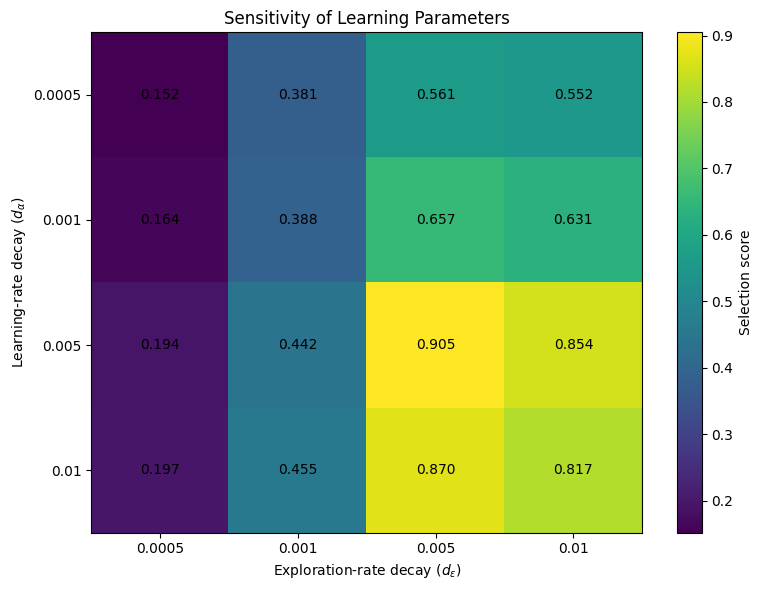

In [20]:
# CREATE HEATMAP MATRIX
heatmap_data = summary.pivot(index="alpha_decay",columns="epsilon_decay",values="selection_score")
print(heatmap_data)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap_data.values,aspect="auto")

# Axis labels
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels([f"{x:g}" for x in heatmap_data.columns])
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels([f"{x:g}" for x in heatmap_data.index])

ax.set_xlabel(r"Exploration-rate decay ")
ax.set_ylabel(r"Learning-rate decay")
ax.set_title("Sensitivity of Learning Parameters")

# WRITE SCORE INSIDE EACH CELL

for i in range(len(heatmap_data.index)):
  for j in range(len(heatmap_data.columns)):
    value = heatmap_data.iloc[i, j]
    ax.text(j,i,f"{value:.3f}",ha="center",va="center")

# Colorbar
cbar = fig.colorbar(im,ax=ax)
cbar.set_label("Selection score")
plt.tight_layout()
plt.show()

In [ ]:
# REWARD-FUNCTION SENSITIVITY ANALYSIS

SELECTED_EPSILON_DECAY = 0.005
SELECTED_ALPHA_DECAY = 0.005

N_EPISODES = 1000
N_RUNS = 10

# Number of independent evaluation episodes after training
N_EVAL_EPISODES = 100

reward_sensitivity_results = []

HIVE_ACTIONS = [0, 2000, 6000, 10000]


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def extract_hive_quantity(action):
    """
    Extract hive quantity from either:
        (0, 0)
        (1, 2000)
        (1, 6000)
        (1, 10000)

    or directly stored quantities:
        0, 2000, 6000, 10000
    """

    if isinstance(action, (tuple, list, np.ndarray)):
        return action[1]

    return action


def calculate_action_proportions(actions):
    """
    Calculate the proportion of each hive action.
    """

    if len(actions) == 0:
        return {
            hive_quantity: np.nan
            for hive_quantity in HIVE_ACTIONS
        }

    hive_actions = [
        extract_hive_quantity(action)
        for action in actions
    ]

    total_actions = len(hive_actions)

    return {
        hive_quantity:
            hive_actions.count(hive_quantity) / total_actions

        for hive_quantity in HIVE_ACTIONS
    }


# ============================================================
# RUN SENSITIVITY SCENARIOS
# ============================================================

for scenario in REWARD_SENSITIVITY_SCENARIOS:

    print(
        "\nRunning reward scenario:",
        scenario["name"]
    )

    for run in range(N_RUNS):

        print("\nRun:", run)

        # ====================================================
        # CREATE MODEL
        # ====================================================

        model = PollinationModel(

            rng=run,

            survival_threshold=
                scenario["survival_threshold"],

            farmer_reward_cap=
                scenario["reward_cap"],

            beekeeper_reward_cap=
                scenario["reward_cap"],

            scale_beekeeper_reward_by_hives=
                scenario["hive_scaling"]
        )


        # ====================================================
        # PHASE 1: TRAINING
        # ====================================================

        for episode in tqdm(
            range(N_EPISODES),
            desc="Training"
        ):

            # -----------------------------------------------
            # Exploration decay
            # -----------------------------------------------

            epsilon = exponential_decay(

                initial_value=
                    BASE_CONFIG["epsilon_initial"],

                minimum_value=
                    BASE_CONFIG["epsilon_min"],

                decay_rate=
                    SELECTED_EPSILON_DECAY,

                episode=
                    episode
            )


            # -----------------------------------------------
            # Learning-rate decay
            # -----------------------------------------------

            alpha = exponential_decay(

                initial_value=
                    BASE_CONFIG["alpha_initial"],

                minimum_value=
                    BASE_CONFIG["alpha_min"],

                decay_rate=
                    SELECTED_ALPHA_DECAY,

                episode=
                    episode
            )


            # -----------------------------------------------
            # Update learning parameters
            # -----------------------------------------------

            for agent in (model.farmers +model.beekeepers):
                agent.exploration_rate = epsilon
                agent.learning_rate = alpha

            # Reset simulation year
            model.current_year = 2025


            # Six annual steps: 2025–2030
            for annual_step in range(6):
                model.step()


        # ====================================================
        # PHASE 2: PREPARE POST-TRAINING EVALUATION
        # ====================================================

        # Turn OFF exploration:
        # agents now select their highest-valued learned action.
        #
        # Turn OFF learning:
        # Q-values remain fixed during evaluation.

        for agent in (model.farmers +model.beekeepers):
            agent.exploration_rate = 0.0
            agent.learning_rate = 0.0


            # -----------------------------------------------
            # Remove TRAINING records
            # -----------------------------------------------
            # We want the following lists to contain ONLY
            # post-training evaluation results.

            agent.rewards = []
            agent.actions_taken = []


        # ====================================================
        # PHASE 3: POST-TRAINING EVALUATION
        # ====================================================

        for eval_episode in tqdm(range(N_EVAL_EPISODES),desc="Evaluation"):
            # Reset year at the beginning of each
            # evaluation episode
            model.current_year = 2025

            # Evaluate learned policy over 2025–2030
            for annual_step in range(6):

                model.step()


        # ====================================================
        # COLLECT POST-TRAINING REWARDS ONLY
        # ====================================================

        farmer_rewards = [

            reward

            for farmer in model.farmers
            for reward in farmer.rewards
        ]


        beekeeper_rewards = [

            reward

            for beekeeper in model.beekeepers
            for reward in beekeeper.rewards
        ]


        # ====================================================
        # COLLECT POST-TRAINING ACTIONS ONLY
        # ====================================================

        farmer_actions = [

            action

            for farmer in model.farmers
            for action in farmer.actions_taken
        ]


        beekeeper_actions = [

            action

            for beekeeper in model.beekeepers
            for action in beekeeper.actions_taken
        ]


        # Convert to hive quantities
        farmer_hive_actions = [

            extract_hive_quantity(action)

            for action in farmer_actions
        ]


        beekeeper_hive_actions = [

            extract_hive_quantity(action)

            for action in beekeeper_actions
        ]


        # ====================================================
        # CALCULATE ACTION PROPORTIONS
        # ====================================================

        farmer_action_props = (
            calculate_action_proportions(
                farmer_actions
            )
        )


        beekeeper_action_props = (
            calculate_action_proportions(
                beekeeper_actions
            )
        )


        # ====================================================
        # STORE RESULTS
        # ====================================================

        reward_sensitivity_results.append({

            # -----------------------------------------------
            # Scenario
            # -----------------------------------------------

            "scenario":
                scenario["name"],

            "run":
                run,

            "survival_threshold":
                scenario["survival_threshold"],

            "reward_cap":
                scenario["reward_cap"],

            "hive_scaling":
                scenario["hive_scaling"],

            "epsilon_decay":
                SELECTED_EPSILON_DECAY,

            "alpha_decay":
                SELECTED_ALPHA_DECAY,

            "training_episodes":
                N_EPISODES,

            "evaluation_episodes":
                N_EVAL_EPISODES,


            # -----------------------------------------------
            # POST-TRAINING mean rewards
            # -----------------------------------------------

            "mean_farmer_reward":
                np.mean(farmer_rewards)
                if farmer_rewards
                else np.nan,

            "mean_beekeeper_reward":
                np.mean(beekeeper_rewards)
                if beekeeper_rewards
                else np.nan,


            # -----------------------------------------------
            # Reward standard deviation during evaluation
            # -----------------------------------------------

            "std_farmer_reward":
                np.std(farmer_rewards, ddof=1)
                if len(farmer_rewards) > 1
                else np.nan,

            "std_beekeeper_reward":
                np.std(beekeeper_rewards, ddof=1)
                if len(beekeeper_rewards) > 1
                else np.nan,



            # FARMER action proportions
            "farmer_action_0_prop":farmer_action_props[0],
            "farmer_action_2000_prop":farmer_action_props[2000],
            "farmer_action_6000_prop":farmer_action_props[6000],
            "farmer_action_10000_prop":farmer_action_props[10000],


            # BEEKEEPER action proportions
            "beekeeper_action_0_prop":beekeeper_action_props[0],
            "beekeeper_action_2000_prop":beekeeper_action_props[2000],
            "beekeeper_action_6000_prop":beekeeper_action_props[6000],
            "beekeeper_action_10000_prop":beekeeper_action_props[10000]

        })


reward_sensitivity_df = pd.DataFrame(reward_sensitivity_results)


# VERIFY ACTION PROPORTIONS

reward_sensitivity_df["farmer_prop_sum"] = (reward_sensitivity_df[["farmer_action_0_prop","farmer_action_2000_prop","farmer_action_6000_prop","farmer_action_10000_prop"]].sum(axis=1))
reward_sensitivity_df["beekeeper_prop_sum"] = (reward_sensitivity_df[["beekeeper_action_0_prop","beekeeper_action_2000_prop","beekeeper_action_6000_prop","beekeeper_action_10000_prop"]].sum(axis=1))

reward_sensitivity_df.to_csv("/content/drive/My Drive/Sensitivity_analysis/reward_function_sensitivity.csv",index=False)


Running reward scenario: Main

Run: 0


Evaluation: 100%|██████████| 100/100 [01:38<00:00,  1.01it/s]



Run: 1


Evaluation: 100%|██████████| 100/100 [01:39<00:00,  1.00it/s]



Run: 2


...

Evaluation: 100%|██████████| 100/100 [01:25<00:00,  1.17it/s]



Running reward scenario: No_hive_scaling

Run: 0


Evaluation: 100%|██████████| 100/100 [01:26<00:00,  1.16it/s]



Run: 1


Training:  92%|█████████▏| 916/1000 [12:50<01:07,  1.24it/s]

In [15]:
df = pd.read_csv("/content/drive/My Drive/Sensitivity_analysis/reward_function_sensitivity.csv")

# SUMMARIZE EACH SENSITIVITY SCENARIO
summary = (
    df.groupby("scenario")
      .agg(
          farmer_reward_mean=("mean_farmer_reward", "mean"),
          farmer_reward_std=("mean_farmer_reward", "std"),

          beekeeper_reward_mean=("mean_beekeeper_reward", "mean"),
          beekeeper_reward_std=("mean_beekeeper_reward", "std"),

          farmer_action_mean=("mean_farmer_action", "mean"),
          farmer_action_std=("mean_farmer_action", "std"),

          beekeeper_action_mean=("mean_beekeeper_action", "mean"),
          beekeeper_action_std=("mean_beekeeper_action", "std")
      )
      .reset_index()
)

# EXTRACT MAIN/BASELINE CONFIGURATION

baseline = summary.loc[summary["scenario"] == "Main"]
baseline = baseline.iloc[0]


# PERCENTAGE CHANGE RELATIVE TO MAIN

def percent_change(value, baseline_value):
    if baseline_value == 0:
        return np.nan
    return 100 * (value - baseline_value) / abs(baseline_value)


# Farmer reward
summary["farmer_reward_change_pct"] = summary[
    "farmer_reward_mean"
].apply(
    lambda x: percent_change(
        x,
        baseline["farmer_reward_mean"]
    )
)

# Beekeeper reward
summary["beekeeper_reward_change_pct"] = summary[
    "beekeeper_reward_mean"
].apply(
    lambda x: percent_change(
        x,
        baseline["beekeeper_reward_mean"]
    )
)

# Farmer action
summary["farmer_action_change_pct"] = summary[
    "farmer_action_mean"
].apply(
    lambda x: percent_change(
        x,
        baseline["farmer_action_mean"]
    )
)

# Beekeeper action
summary["beekeeper_action_change_pct"] = summary[
    "beekeeper_action_mean"
].apply(
    lambda x: percent_change(
        x,
        baseline["beekeeper_action_mean"]
    )
)

# ABSOLUTE DIFFERENCES FROM MAIN

summary["farmer_reward_difference"] = (summary["farmer_reward_mean"]- baseline["farmer_reward_mean"])
summary["beekeeper_reward_difference"] = (summary["beekeeper_reward_mean"] - baseline["beekeeper_reward_mean"])

summary["farmer_action_difference"] = (summary["farmer_action_mean"]- baseline["farmer_action_mean"])
summary["beekeeper_action_difference"] = (summary["beekeeper_action_mean"]- baseline["beekeeper_action_mean"])

# PUT MAIN SCENARIO FIRST

summary["order"] = np.where(summary["scenario"] == "Main", 0, 1)

summary = (
    summary.sort_values(["order", "scenario"])
           .drop(columns="order")
           .reset_index(drop=True)
)

summary

Index(['scenario', 'run', 'survival_threshold', 'reward_cap', 'hive_scaling', 'epsilon_decay', 'alpha_decay', 'mean_farmer_reward', 'mean_beekeeper_reward', 'mean_farmer_action',
       'mean_beekeeper_action'],
      dtype='object')
  scenario  run  survival_threshold  reward_cap  hive_scaling  epsilon_decay  alpha_decay  mean_farmer_reward  mean_beekeeper_reward  mean_farmer_action  mean_beekeeper_action
0     Main    0                 0.7         2.0          True          0.005        0.005            0.043051               0.071791         6449.629630            4139.518519
1     Main    1                 0.7         2.0          True          0.005        0.005            0.042960               0.059420         6430.000000            4204.925926
2     Main    2                 0.7         2.0          True          0.005        0.005            0.042904               0.063063         6562.148148            4191.851852
3     Main    3                 0.7         2.0          True 

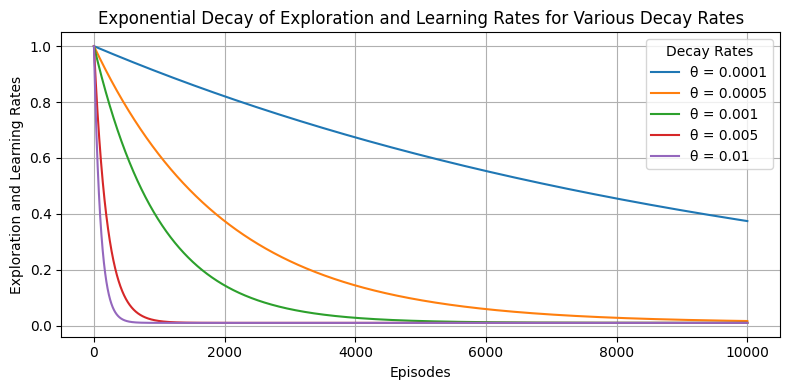

In [3]:
# Define constants
max_exploration_rate = 1.0
min_exploration_rate = 0.01
decay_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01]
num_episodes = 10000

def get_exploration_rate(episode, decay_rate):
    return min_exploration_rate + (max_exploration_rate - min_exploration_rate) * np.exp(-decay_rate * episode)

# Plotting
plt.figure(figsize=(8, 4))

for rate in decay_rates:
    exploration_rates = [get_exploration_rate(ep, rate) for ep in range(num_episodes)]
    plt.plot(exploration_rates, label=f"θ = {rate}")

plt.xlabel("Episodes")
plt.ylabel("Exploration and Learning Rates")
plt.title("Exponential Decay of Exploration and Learning Rates for Various Decay Rates")
plt.legend(title="Decay Rates", loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


## Non-RL ABM

In [ ]:
class FarmerAgent_StandAlone_ABM(Agent):
    def __init__(self, model, region):
        super().__init__(model)
        self.region = region
        self.actions_taken = []
        self.actions_taken_history = []
        self.possible_actions = [(0, 0), (1, 2000), (1, 6000), (1, 10000)]

    @classmethod
    def create_agents(cls, model, n, region):
        agents = []
        for i in range(n):
            agent = cls(model=model, region=region)
            agents.append(agent)
        return agents

    def step(self):
        action = random.choice(self.possible_actions)
        self.actions_taken.append(action[1]) # number of hives is only needed
        self.region.pollination_requests = action # (0,0) or (1, number of hives)

class BeekeeperAgent_StandAlone_ABM(Agent):
    def __init__(self, model, region):
        super().__init__(model)
        self.chosen_month = random.choice([7,8])
        self.region = region
        self.actions_taken = []
        self.actions_taken_history = []
        self.possible_actions = [(0, 0), (1, 2000), (1, 6000), (1, 10000)]

    @classmethod
    def create_agents(cls, model, n, region):
        agents = []
        for i in range(n):
            agent = cls(model=model, region=region)
            agents.append(agent)
        return agents

    def step(self):
        # randomly choosing one of two months July or August
        self.chosen_month = random.choice([7,8])
        action = random.choice(self.possible_actions)
        self.actions_taken.append(action[1]) # number of hives is only needed
        self.region.pollination_offers = action # (0,0) or (1, number of hives)

class PollinationModel_StandAlone_ABM(Model):
  def __init__(self, seed=None):
    super().__init__(seed=seed)
    self.current_year = 2025

    # Create regions
    self.regions = [Region_StandAlone_ABM(region_id = i) for i in [2402, 2403, 2404, 2405, 2406, 2408, 2409, 2410, 2411]]

    # Storing agents
    self.farmers = []
    self.beekeepers = []
    self.agents_list = []

    # Create agents
    for region in self.regions:
      farmer = FarmerAgent_StandAlone_ABM.create_agents(model = self, n=1 , region = region)
      beekeeper = BeekeeperAgent_StandAlone_ABM.create_agents(model = self, n=1, region = region)

      self.farmers.extend(farmer)
      self.beekeepers.extend(beekeeper)

      self.agents_list.extend(farmer)
      self.agents_list.extend(beekeeper)


  def step(self):
    self.update_environment(self.current_year)

    for farmer_agent in self.farmers:
      farmer_agent.step()

    for beekeeper_agent in self.beekeepers:
      beekeeper_agent.step()

    self.process_pollination()
    self.current_year += 1


  def process_pollination(self):
    for regionn in self.regions:
      F_requested, F_n = regionn.pollination_requests
      B_offered, B_n = regionn.pollination_offers

      if F_requested == 1 and B_offered == 1: # the pollination service is provided only if the farmer agents request and the beekeeper agents offer
        matched_hives = min(F_n, B_n)
        regionn.pollination_match_rate_of_each_episode.append(min(F_n, B_n)/max(F_n,B_n))

        # Predict crop yield based on environmental factors and the number of hives requested in the pollination service
        current_yields = regionn.crop_yield_prediction(XGBoost_model = Best_XGBoost, year=self.current_year, Prcp=regionn.annual_precipitation,
                                                        T_max=regionn.annual_temperature, soil=regionn.soil, Num_hives=matched_hives)
        regionn.yields_of_each_episode.append(current_yields)

        for beekeeper in self.beekeepers:
          if beekeeper.region.id == regionn.id:
            if beekeeper.chosen_month == 7:
              survival_rate = regionn.Beehive_survival_prediction(RSF_model=RSF_model, year=self.current_year, month=7,
                                                                DEM=regionn.DEM, Prcp=regionn.July_precipitation, T_max=regionn.July_temperature)
              regionn.survival_of_each_episode.append(survival_rate)
            else:
              survival_rate = regionn.Beehive_survival_prediction(RSF_model=RSF_model, year=self.current_year, month=8,
                                                                DEM=regionn.DEM, Prcp=regionn.August_precipitation, T_max=regionn.August_temperature)
              regionn.survival_of_each_episode.append(survival_rate)


      else:
        current_yields = regionn.crop_yield_prediction(XGBoost_model = Best_XGBoost, year=self.current_year, Prcp=regionn.annual_precipitation,
                                                        T_max=regionn.annual_temperature, soil=regionn.soil, Num_hives=0)
        survival_rate = 1.0

        regionn.yields_of_each_episode.append(current_yields)
        regionn.survival_of_each_episode.append(survival_rate)
        regionn.pollination_match_rate_of_each_episode.append(0)



  def update_environment(self, current_year):
    annual_array = pd.read_csv(f'/home/navid94/climate_variables_{current_year}_RCP85_annual_average_for_crop_yield.csv')
    July_Aug_array = pd.read_csv(f'/home/navid94/climate_variables_{current_year}_RCP85_July_Aug.csv')
    Soil_array = pd.read_csv('/home/navid94/Soil variables.csv')
    DEM_df = pd.read_csv('/home/navid94/Zonal_statistics_DEM.csv')
    DEM = DEM_df[['CAR_ID', 'MEAN']].copy()
    DEM_array = DEM.rename(columns={'MEAN': 'DEM'})

    for region in self.regions:
      region.annual_temperature = annual_array[annual_array['CAR_ID'] == region.id]['T_max'].values[0]
      region.annual_precipitation = annual_array[annual_array['CAR_ID'] == region.id]['Precipitation'].values[0]
      region.July_temperature = July_Aug_array[July_Aug_array['CAR_ID'] == region.id][f'Tmax_{current_year}_7'].values[0]
      region.July_precipitation = July_Aug_array[July_Aug_array['CAR_ID'] == region.id][f'Total Prcp_{current_year}_7'].values[0]
      region.August_temperature = July_Aug_array[July_Aug_array['CAR_ID'] == region.id][f'Tmax_{current_year}_8'].values[0]
      region.August_precipitation = July_Aug_array[July_Aug_array['CAR_ID'] == region.id][f'Total Prcp_{current_year}_8'].values[0]

      region.soil = Soil_array[Soil_array['CAR_ID'] == region.id]['Saturated hydraulic conductivity'].values[0]
      region.DEM = DEM_array[DEM_array['CAR_ID'] == region.id]['DEM'].values[0]


class Region_StandAlone_ABM:
  def __init__(self, region_id):
    self.id = region_id #[2402, 2403, 2404, 2405, 2406, 2408, 2409, 2410, 2411]
    self.annual_temperature= None
    self.annual_precipitation= None
    self.July_temperature= None
    self.July_precipitation= None
    self.August_temperature= None
    self.August_precipitation= None
    self.soil= None
    self.DEM= None
    self.pollination_requests= (0, 0)
    self.pollination_offers= (0, 0)
    self.yields_of_each_episode = []
    self.survival_of_each_episode=[]
    self.pollination_match_rate_of_each_episode = []
    self.yields_history=[]
    self.survival_history=[]
    self.pollination_match_rate_history=[]

  # Defining a function for the calculation of beehive survival probability for the given CAR in the given year
  def Beehive_survival_prediction(self, RSF_model, year, month, DEM, Prcp, T_max):
    monthly_survival_probability = pd.DataFrame([{
        "Year": year,
        "Month":month,
        "DEM": DEM,
        "Precipitation": Prcp,
        "T_max": T_max,
    }])

    # Load the calibration model and unique_times_real
    with open("/home/navid94/calibration_data_1.pkl", "rb") as f:
      calibration_data = pickle.load(f)

    iso_reg_model = calibration_data["iso_reg"]
    unique_times_real = calibration_data["unique_times_real"]

    # Predict survival probabilities on new data
    pred_surv_probs_new = RSF_model.predict_survival_function(monthly_survival_probability.values)

    for _,sf in enumerate(pred_surv_probs_new):
      # Interpolate predictions to match calibration times
      interp_func_new = interp1d(RSF_model.unique_times_, sf.y, kind='nearest', fill_value='extrapolate')
      pred_surv_probs_new_interp = interp_func_new(unique_times_real)

      # Apply the saved isotonic regression model for calibration
      calibrated_pred_surv_probs = iso_reg_model.transform(pred_surv_probs_new_interp)

    return np.mean(calibrated_pred_surv_probs) #monthly survival probability for July and August

  # Yield prediction function for the given CAR, year, RCP scenario, and the number of beehives provided in the pollination services
  # This function is going to be called in the agent-based model
  def crop_yield_prediction(self, XGBoost_model, year, Prcp, T_max, soil, Num_hives): # Best_XGBoost is the trained model with the optimal hyperparameters
    # Create a row DataFrame
    annual_yield = pd.DataFrame([{
        "Year": year,
        "Precipitation":Prcp,
        "T_max": T_max,
        "Saturated hydraulic conductivity": soil,
        "Honeybee census": Num_hives,
    }])

    yield_pred = XGBoost_model.predict(annual_yield)
    if yield_pred < 0: # Yield prediction cannot be negative
      yield_pred = 0
    return yield_pred[0]

In [ ]:
num_episodes = 10000
max_steps_per_episode = 6  # for 6 years (2025-2030)
num_runs = 30

for run in range(1, num_runs + 1):
    print(f"   -> Run {run}/30")
    # Create a new model instance
    pollination_model_ABM = PollinationModel_StandAlone_ABM()

    for episode in range(num_episodes):
      # Reseting the environment of the model
      pollination_model_ABM.current_year = 2025

      for agent in pollination_model_ABM.agents_list:
        agent.actions_taken = []

      for region in pollination_model_ABM.regions:
        region.yields_of_each_episode = []
        region.survival_of_each_episode=[]
        region.pollination_match_rate_of_each_episode = []

      for i in range(max_steps_per_episode): # one episode
          pollination_model_ABM.step()

      for agent in pollination_model_ABM.agents_list:
        agent.actions_taken_history.append(agent.actions_taken)

      for regionnn in pollination_model_ABM.regions:
        regionnn.yields_history.append(regionnn.yields_of_each_episode)
        regionnn.survival_history.append(regionnn.survival_of_each_episode)
        regionnn.pollination_match_rate_history.append(regionnn.pollination_match_rate_of_each_episode)


    # --- Save Results for this run ---
    save_base_path = "/home/navid94/Non_RL_ABM_outputs"

    # Save Farmers
    for farmer in pollination_model_ABM.farmers:
        region_id = str(farmer.region.id)
        with open(f"{save_base_path}/run_{run}_Farmer_{region_id}_actions_taken.pkl", "wb") as h:
            pickle.dump(np.array(farmer.actions_taken_history).reshape(num_episodes, -1), h)

    # Save Beekeepers
    for beekeeper in pollination_model_ABM.beekeepers:
        region_id = str(beekeeper.region.id)
        with open(f"{save_base_path}/run_{run}_Beekeeper_{region_id}_actions_taken.pkl", "wb") as hh:
            pickle.dump(np.array(beekeeper.actions_taken_history).reshape(num_episodes, -1), hh)

    for region in pollination_model_ABM.regions:
        region_id = str(region.id)
        with open(f"{save_base_path}/run_{run}_Region_{region_id}_accumulated_yields.pkl", "wb") as fff:
            pickle.dump(np.array(region.yields_history).reshape(num_episodes, -1), fff)
        with open(f"{save_base_path}/run_{run}_Region_{region_id}_survival_probability.pkl", "wb") as ggg:
            pickle.dump(np.array(region.survival_history).reshape(num_episodes, -1), ggg)

# Analysing results

## Average cumulative rewards over episodes

In [ ]:
rewards_dir = 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/ABM_outputs/Optimized_configuration_last_episode/'


# Regular expression to extract agent type
pattern = re.compile(r'.*_(Farmer|Beekeeper)_(\d+)_rewards\.pkl')

# Organize rewards by agent type
reward_by_agent = defaultdict(list)

for fname in os.listdir(rewards_dir):
    if fname.endswith('_rewards.pkl'):
        match = pattern.match(fname)
        if match:
            agent_type = match.group(1)
            with open(os.path.join(rewards_dir, fname), 'rb') as f:
                rewards = pickle.load(f)  # shape: (10000, 6)
            if rewards.shape == (10000, 6):
                cumulative_rewards = rewards.sum(axis=1)  # (10000,)
                reward_by_agent[agent_type].append(cumulative_rewards)

# Custom colors for agent types
agent_colors = {
    'Farmer': '#D55E00',
    'Beekeeper': '#0072B2'
}

# Plot for each agent type
for agent_type, reward_list in reward_by_agent.items():
    reward_matrix = np.stack(reward_list)  # shape: (N_runs, 10000)
    mean_rewards = reward_matrix.mean(axis=0)
    std_rewards = reward_matrix.std(axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(mean_rewards, label='Mean cumulative reward', color=agent_colors[agent_type])
    plt.fill_between(range(10000), mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.3, label='±1 Std dev', color=agent_colors[agent_type])
    plt.title(f'Cumulative reward curve for {agent_type} agents')
    plt.xlabel('Episode')
    plt.ylabel('Cumulative reward (Mean ± Std dev)')
    plt.grid(True)
    plt.tight_layout()
    plt.legend(loc='lower right')
    plt.show()


## Q-value convergence

In [ ]:
# Regular expression to extract agent type
pattern = re.compile(r'run_\d+_(Farmer|Beekeeper)_(\d+)_q_value\.pkl')


# Path to Q-values
qvalues_dir = 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/ABM_outputs/Optimized_configuration_last_episode/'


# Store Q-values by agent type
qvalues_by_agent = defaultdict(list)

for fname in os.listdir(qvalues_dir):
    if fname.endswith('_q_value.pkl'):
        match = pattern.match(fname)
        if match:
            agent_type = match.group(1)
            with open(os.path.join(qvalues_dir, fname), 'rb') as f:
                qvalues = pickle.load(f)  # shape: (10000, 6)

            if qvalues.shape == (10000, 6):
                mean_q_per_episode = qvalues.mean(axis=1)  # shape: (10000,)
                qvalues_by_agent[agent_type].append(mean_q_per_episode)
            else:
                print(f"Skipping {fname}: unexpected shape {qvalues.shape}")

# Custom colors for agent types
agent_colors = {
    'Farmer': '#D55E00',
    'Beekeeper': '#0072B2'
}

# Plot for each agent type
for agent_type, qvalue_list in qvalues_by_agent.items():
    qvalue_matrix = np.stack(qvalue_list)  # shape: (N_agents, 10000)
    mean_q = qvalue_matrix.mean(axis=0)
    std_q = qvalue_matrix.std(axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(mean_q, color=agent_colors[agent_type], label='Mean per-episode Q-Value')
    plt.fill_between(range(10000),
                     mean_q - std_q,
                     mean_q + std_q,
                     alpha=0.3,
                     color=agent_colors[agent_type], label='±1 Std dev')
    plt.title(f'Per-episode Q-Value convergence over episodes for {agent_type} agents')
    plt.xlabel('Episode')
    plt.ylabel('Per-episode Q-Value of selected actions (Mean ± Std dev)')
    plt.grid(True)
    plt.tight_layout()
    plt.legend(loc='lower right')
    plt.show()

## Action distributions by region: RL-ABM vs. Non-RL ABM

In [ ]:

# ==== Configuration ====
rl_dir = 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/ABM_outputs/Optimized_configuration_last_episode/'
baseline_dir = 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/Non_RL_ABM_outputs_10000/'
regions = [2402, 2403, 2404, 2405, 2406, 2408, 2409, 2410, 2411]
action_levels = [0, 2000, 6000, 10000]
pattern = re.compile(r".*run_(\d+)_([A-Za-z]+)_(\d+)_actions_taken\.pkl")

# ==== Load data ====
def load_actions_by_region(directory):
    region_actions = defaultdict(lambda: defaultdict(list))
    for fname in os.listdir(directory):
        if not fname.endswith('_actions_taken.pkl'):
            continue
        match = pattern.match(fname)
        if match:
            run, agent_type, region_id = int(match[1]), match[2], int(match[3])
            if region_id not in regions:
                continue
            with open(os.path.join(directory, fname), 'rb') as f:
                actions = pickle.load(f)
            if actions.shape != (10000, 6):
                print(f"Skipping {fname}: wrong shape {actions.shape}")
                continue
            region_actions[region_id][agent_type].extend(actions.flatten())
    return region_actions

rl_actions_by_region = load_actions_by_region(rl_dir)
baseline_actions_by_region = load_actions_by_region(baseline_dir)

# ==== Count frequencies ====
def count_action_frequencies(flat_list):
    return pd.Series(flat_list).value_counts().reindex(action_levels, fill_value=0)

# ==== Set style ====
sns.set(style="whitegrid", font_scale=1.2)

# ==== Create 3x3 subplot ====
fig, axes = plt.subplots(3, 3, figsize=(40, 30))
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]

    df_counts = []
    for agent in ['Farmer', 'Beekeeper']:
        rl = count_action_frequencies(rl_actions_by_region[region][agent])
        base = count_action_frequencies(baseline_actions_by_region[region][agent])
        for action in action_levels:
            df_counts.append({
                'Agent': agent,
                'Action': action,
                'Model': 'RL-ABM',
                'Count': rl[action]
            })
            df_counts.append({
                'Agent': agent,
                'Action': action,
                'Model': 'Non-RL ABM',
                'Count': base[action]
            })

    df_plot = pd.DataFrame(df_counts)
    df_plot['Agent_Action'] = df_plot['Agent'] + ": " + df_plot['Action'].astype(str)

    sns.barplot(
        data=df_plot,
        x='Agent_Action', y='Count', hue='Model',
        ax=ax, palette='colorblind'
    )

    ax.set_title(f"Region {region}", fontsize=30)
    ax.set_xlabel("", fontsize=30)
    ax.set_ylabel("Frequency", fontsize=30)
    ax.tick_params(axis='x', rotation=90, labelsize=30)
    ax.tick_params(axis='y', labelsize=30)
    ax.yaxis.offsetText.set_fontsize(30)
    ax.get_legend().remove()


if len(axes) > len(regions):
    for i in range(len(regions), len(axes)):
        fig.delaxes(axes[i])


handles, labels = ax.get_legend_handles_labels()

plt.suptitle("Action distributions by region: RL-ABM vs. Non-RL ABM", fontsize=38, y=0.98)

fig.legend(
    handles, labels, title="Model",
    loc='upper center', bbox_to_anchor=(0.5, 0.955), ncol=2,
    fontsize=30, title_fontsize=30
)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])



## Temporal action distributions per region

In [ ]:
# ==== Configuration ====
rl_dir = 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/ABM_outputs/Optimized_configuration_last_episode/'
baseline_dir = 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/Non_RL_ABM_outputs_10000/'
regions = [2402, 2403, 2404, 2405, 2406, 2408, 2409, 2410, 2411]
action_levels = [0, 2000, 6000, 10000]
pattern = re.compile(r".*run_(\d+)_([A-Za-z]+)_(\d+)_actions_taken\.pkl")

# ==== Function to count actions by time step and region ====
def count_actions_by_region(directory):
    regional_data = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    for fname in os.listdir(directory):
        if not fname.endswith('_actions_taken.pkl'):
            continue
        match = pattern.match(fname)
        if match:
            run, agent_type, region_id = int(match[1]), match[2], int(match[3])
            if region_id not in regions:
                continue
            with open(os.path.join(directory, fname), 'rb') as f:
                actions = pickle.load(f)
            if actions.shape != (10000, 6):
                print(f"Skipping {fname}: wrong shape {actions.shape}")
                continue
            for t in range(6):
                timestep_actions = actions[:, t]
                for action in action_levels:
                    count = np.sum(timestep_actions == action)
                    regional_data[region_id][agent_type][(action, t)] += count
    return regional_data

# ==== Load data ====
rl_counts = count_actions_by_region(rl_dir)
baseline_counts = count_actions_by_region(baseline_dir)

# ==== Prepare dataframe for plotting ====
def prepare_df(data, model_label):
    rows = []
    for region in regions:
        for agent in ['Farmer', 'Beekeeper']:
            total_per_ts = defaultdict(int)
            for (action, t), count in data[region][agent].items():
                total_per_ts[t] += count
            for (action, t), count in data[region][agent].items():
                prob = count / total_per_ts[t] if total_per_ts[t] > 0 else 0
                rows.append({
                    'Region': region,
                    'Agent': agent,
                    'TimeStep': t,
                    'Action': action,
                    'Probability': prob,
                    'Model': model_label,
                    'Label': f"{agent}: {action}"
                })
    return pd.DataFrame(rows)

df_rl = prepare_df(rl_counts, 'RL-ABM')
df_baseline = prepare_df(baseline_counts, 'Non-RL ABM')

# ==== Plotting function with improvements ====
def plot_temporal_actions(df, model_label):
    sns.set(style='whitegrid')
    fig, axes = plt.subplots(3, 3, figsize=(36, 24))
    axes = axes.flatten()

    for idx, region in enumerate(regions):
        ax = axes[idx]
        df_region = df[df['Region'] == region]

        sns.barplot(
            data=df_region,
            x='TimeStep', y='Probability', hue='Label',
            ax=ax, palette=custom_palette, edgecolor=None
        )

        ax.set_title(f"Region {region}", fontsize=30)
        ax.set_xticks(range(6))
        ax.set_xticklabels([str(year) for year in range(2025, 2031)], fontsize=26)
        ax.set_xlabel("Year", fontsize=28)
        ax.set_ylabel("Action Probability", fontsize=28)
        ax.tick_params(axis='both', labelsize=26)
        ax.get_legend().remove()

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels, title="Agent & Action",
        loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4,
        fontsize=28, title_fontsize=28
    )

    plt.suptitle(f"Temporal action distributions per region ({model_label})", fontsize=38, y=1.07)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

custom_palette = {
    'Farmer: 0': '#0072B2',       # Blue
    'Farmer: 2000': '#009E73',    # Green
    'Farmer: 6000': '#E69F00',    # Orange
    'Farmer: 10000': '#56B4E9',   # Sky Blue
    'Beekeeper: 0': '#D55E00',    # Vermilion
    'Beekeeper: 2000': '#F0E442', # Yellow
    'Beekeeper: 6000': '#000000', # Black
    'Beekeeper: 10000': '#999999' # Grey
}
plot_temporal_actions(df_rl, 'RL-ABM')
plot_temporal_actions(df_baseline, 'Non-RL ABM')


## Per-Region Pareto Front Comparison: RL-ABM vs Non-RL ABM

In [ ]:
# === Configuration ===
rl_dir = 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/ABM_outputs/Optimized_configuration_last_episode/yields_and_survival/'
non_rl_dir = 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/Non_RL_ABM_outputs_10000/yields_and_survival/'

runs = range(1, 31)
regions = [2402, 2403, 2404, 2405, 2406, 2408, 2409, 2410, 2411]

# === Pareto Front Calculation ===
def is_pareto_efficient(points):
    n = len(points)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j:
                if np.all(points[j] >= points[i]) and np.any(points[j] > points[i]):
                    is_efficient[i] = False
                    break
    return is_efficient

# === Data Loading Function ===
def load_model_points(data_dir):
    region_points = defaultdict(list)
    for run in runs:
        for region in regions:
            yfile = f"run_{run}_Region_{region}_accumulated_yields.pkl"
            sfile = f"run_{run}_Region_{region}_survival_probability.pkl"
            ypath, spath = os.path.join(data_dir, yfile), os.path.join(data_dir, sfile)

            if os.path.exists(ypath) and os.path.exists(spath):
                with open(ypath, 'rb') as yf, open(spath, 'rb') as sf:
                    y = pickle.load(yf)  # shape: (10000, 6)
                    s = pickle.load(sf)
                region_points[region].append([np.sum(y[-1]), np.mean(s[-1])])
            else:
                print(f"Missing file: {yfile} or {sfile}")
    return region_points

# === Load RL and Non-RL data ===
rl_points = load_model_points(rl_dir)
non_rl_points = load_model_points(non_rl_dir)

# === Plotting ===
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]

    rl = np.array(rl_points[region])
    non_rl = np.array(non_rl_points[region])

    if len(rl) == 0 or len(non_rl) == 0:
        continue

    rl_pareto = rl[is_pareto_efficient(rl)]
    non_rl_pareto = non_rl[is_pareto_efficient(non_rl)]

    # Plot all points
    ax.scatter(non_rl[:, 0], non_rl[:, 1], alpha=0.3, color='skyblue', label='Non-RL (all)' if idx == 0 else "")
    ax.scatter(rl[:, 0], rl[:, 1], alpha=0.3, color='orange', label='RL-ABM (all)' if idx == 0 else "")

    # Plot Pareto fronts
    ax.scatter(non_rl_pareto[:, 0], non_rl_pareto[:, 1], color='blue', label='Non-RL Pareto' if idx == 0 else "")
    ax.plot(non_rl_pareto[np.argsort(non_rl_pareto[:, 0]), 0],
            non_rl_pareto[np.argsort(non_rl_pareto[:, 0]), 1],
            color='blue', linestyle='--', alpha=0.8)

    ax.scatter(rl_pareto[:, 0], rl_pareto[:, 1], color='red', label='RL-ABM Pareto' if idx == 0 else "")
    ax.plot(rl_pareto[np.argsort(rl_pareto[:, 0]), 0],
            rl_pareto[np.argsort(rl_pareto[:, 0]), 1],
            color='red', linestyle='--', alpha=0.8)

    ax.set_title(f"Region {region}", fontsize=16)
    ax.set_xlabel("Cumulative crop yield", fontsize=16)
    ax.set_ylabel("Avg. survival probability", fontsize=16)
    ax.set_ylim(0.0, 1.1)
    ax.grid(True)
    ax.tick_params(labelsize=14)

# Remove unused axes
for i in range(len(regions), len(axes)):
    fig.delaxes(axes[i])

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.008), ncol=2, fontsize=16)
fig.suptitle("Per-Region Pareto Front Comparison: RL-ABM vs Non-RL ABM", fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


##Regional comparison of trade-offs between cumulative crop yield and beehive survival across models

In [ ]:
# Parameters
models = ['RL-ABM', 'Non-RL ABM']
folders = {
    'RL-ABM': 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/ABM_outputs/Optimized_configuration_last_episode/yields_and_survival/',
    'Non-RL ABM': 'C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/Non_RL_ABM_outputs_10000/yields_and_survival/'
}

# === Load data ===
def load_last_episode_per_region(folder, metric):
    records = []
    for fname in os.listdir(folder):
        if not fname.endswith(f"{metric}.pkl"):
            continue

        parts = fname.replace('.pkl', '').split('_')
        run = int(parts[1])
        region = int(parts[3])

        with open(os.path.join(folder, fname), 'rb') as f:
            data = pickle.load(f)  # shape: (10000, 6)
        last_episode = data[9999]  # shape: (6,)
        records.append({
            'Region': region,
            'Run': run,
            'Values': last_episode
        })
    return pd.DataFrame(records)

# === Merge and compute per-run averages ===
dfs = []

for model in models:
    yield_df = load_last_episode_per_region(folders[model], 'accumulated_yields')
    survival_df = load_last_episode_per_region(folders[model], 'survival_probability')

    df_merged = pd.merge(yield_df, survival_df, on=['Region', 'Run'], suffixes=('_yield', '_survival'))

    for _, row in df_merged.iterrows():
        dfs.append({
            'Region': row['Region'],
            'Run': row['Run'],
            'Model': model,
            'Total_Yield': np.sum(row['Values_yield']),
            'Avg_Survival': np.mean(row['Values_survival'])
        })

df_all = pd.DataFrame(dfs)
df_all.to_csv('C:/Users/Navid Mahdizadeh/Documents/Compute Canada files/ABM_thesis/files for the whole run/ABM_outputs/Optimized_configuration_last_episode/yields_and_survival/dataframe.csv', index=False)

# === Compute mean and std across runs for each Region-Model ===
records = []
for (region, model), group in df_all.groupby(['Region', 'Model']):
    avg_yield = group['Total_Yield'].mean()
    std_yield = group['Total_Yield'].std()
    avg_survival = group['Avg_Survival'].mean()
    std_survival = group['Avg_Survival'].std()

    records.append({
        'Region': region,
        'Model': model,
        'Yield': avg_yield,
        'Yield_SD': std_yield,
        'Survival': avg_survival,
        'Survival_SD': std_survival
    })

df_pareto = pd.DataFrame(records)



# === Plotting with error bars ===
sns.set(style='whitegrid')
regions = df_pareto['Region'].unique()
n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

palette = sns.color_palette('colorblind')
model_colors = dict(zip(df_pareto['Model'].unique(), palette))

for idx, region in enumerate(regions):
    ax = axes[idx]
    df_region = df_pareto[df_pareto['Region'] == region]

    for model in df_region['Model'].unique():
        row = df_region[df_region['Model'] == model].iloc[0]

        ax.scatter(
            row['Survival'], row['Yield'],
            color=model_colors[model],
            s=60,
            label=model if idx == 0 else None  # only label in first subplot
        )

        ax.errorbar(
            row['Survival'], row['Yield'],
            xerr=row['Survival_SD'],
            yerr=row['Yield_SD'],
            fmt='none',
            ecolor=model_colors[model],
            elinewidth=2,
            capsize=5,
            alpha=0.7
        )

    ax.set_title(f"Region {region}", fontsize=18)
    ax.tick_params(axis='both', labelsize=14)

# Axis labels and formatting
for ax in axes:
    ax.set_xlabel("Average beehive survival", fontsize=16)
    ax.set_ylabel("Cumulative crop yield", fontsize=16)

# Turn off unused subplots
for i in range(len(regions), len(axes)):
    fig.delaxes(axes[i])

# Shared legend
fig.legend(
    handles=[plt.Line2D([0], [0], marker='o', color='w', label=model,
                        markerfacecolor=model_colors[model], markersize=12)
             for model in df_pareto['Model'].unique()],
    title="Model",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2,
    fontsize=16,
    title_fontsize=18,
    frameon=False
)

fig.subplots_adjust(top=0.90, hspace=0.3)
fig.suptitle("Regional comparison of trade-offs between cumulative crop yield and beehive survival across models", fontsize=20, y=1.08)
plt.show()